<a href="https://colab.research.google.com/github/ezNobson/ML-AGH/blob/main/EDA_AGH_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA on dataset ERA5**
---
Autor: Michał Dyrek
---
Data: 2025-12-04
---
Data Science
---

## **Dataset**
This notebook provides EDA for "ERA5" dataset throught years 1996-2025. Lolcalization of investigated region is Tokyo, Japan.

Variables:

- **10m u-component of wind** - `u10` - Eastward component of the 'neutral wind', at a height of 10 metres above the surface of the Earth.
- **10m v-component of wind** - `v10` - Northward component of the 'neutral wind', at a height of 10 metres above the surface of the Earth.
- **2m dewpoint temperature** - `d2m` - Temperature to which the air, at 2 metres above the surface of the Earth, would have to be cooled for saturation to occur.
- **2m temperature** - `t2m` - Temperature of air at 2m above the surface of land, sea or in-land waters.
- **Total precipitation** - `tp` - This parameter is the accumulated liquid and frozen water, comprising rain and snow, that falls to the Earth's surface.
- **Skin temperature** - `skt` - This parameter is the temperature of the surface of the Earth.
- **Surface net solar radiation** - `ssr` - Surface net solar radiation is the sunlight energy reaching the ground (direct + diffuse) minus the portion reflected by the surface.
- **Surface net thermal radiation** - `str` - Thermal energy at the surface equal to downward longwave from the atmosphere minus the upward longwave emitted by the surface.
- **Total cloud cover** - `tcc` - Fraction (0–1) of the sky area covered by clouds, combining clouds from all model levels with assumptions about their vertical overlap.
- **Evaporation** - `e` - This parameter is the accumulated amount of water that has evaporated from the Earth's surface.
- **Volumetric soil water layer 1** - `swvl1` - This parameter is the volume of water in soil layer 1 (0 - 7cm, the surface is at 0cm).


In [ ]:
import pandas as pd
import numpy as np

Library that let us load file with extension `.grib`

In [ ]:
!pip install cfgrib

In [ ]:
import xarray as xr
import cfgrib

In [ ]:
# We turn off the FutureWarinings
xr.set_options(use_new_combine_kwarg_defaults=True)

In [ ]:
data_path = "/content/dataTokyo.grib"

In [ ]:
datasets = cfgrib.open_datasets(data_path)
datasets

[<xarray.Dataset> Size: 2MB
 Dimensions:              (time: 10957, latitude: 5, longitude: 7)
 Coordinates:
   * time                 (time) datetime64[ns] 88kB 1996-01-01T06:00:00 ... 2...
   * latitude             (latitude) float64 40B 36.0 35.75 35.5 35.25 35.0
   * longitude            (longitude) float64 56B 139.0 139.2 ... 140.2 140.5
     number               int64 8B 0
     step                 timedelta64[ns] 8B 00:00:00
     depthBelowLandLayer  float64 8B 0.0
     valid_time           (time) datetime64[ns] 88kB ...
 Data variables:
     swvl1                (time, latitude, longitude) float32 2MB ...
 Attributes:
     GRIB_edition:            1
     GRIB_centre:             ecmf
     GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
     GRIB_subCentre:          0
     Conventions:             CF-1.7
     institution:             European Centre for Medium-Range Weather Forecasts,
 <xarray.Dataset> Size: 9MB
 Dimensions:     (time: 10957, latitude

In [ ]:
for i, ds in enumerate(datasets):
    print(f"\nDataset {i}:")
    print("Features:", list(ds.data_vars))
    print("Time range:", ds.time.values[0], "→", ds.time.values[-1])
    print("Number of time steps:", ds.time.size)



Dataset 0:
Features: ['swvl1']
Time range: 1996-01-01T06:00:00.000000000 → 2025-12-30T06:00:00.000000000
Number of time steps: 10957

Dataset 1:
Features: ['tcc', 'u10', 'v10', 't2m', 'd2m', 'skt']
Time range: 1996-01-01T06:00:00.000000000 → 2025-12-30T06:00:00.000000000
Number of time steps: 10957

Dataset 2:
Features: ['ssr', 'str', 'e', 'tp']
Time range: 1995-12-31T18:00:00.000000000 → 2025-12-29T18:00:00.000000000
Number of time steps: 10957


So we see that we have a 3 different dataframes and in each there is a different our. We delete information about a hour because what the thing that interests us is an inforamtion about the specific day.

In [ ]:
# 1 Dataset contains feature with soil water layer 1
df_soil = datasets[0].to_dataframe().reset_index()
# 2 Dataset contains features with atmospheric infromations such as components of wind and temperatures
df_atmos = datasets[1].to_dataframe().reset_index()
# 3 Dataset contains features with that where accumulated from 6 hours (thats why there is a different hour in raw data)
df_accum = datasets[2].to_dataframe().reset_index()

In [ ]:
print(f"DF soil: \n {df_soil.head()}")
print(f"DF atmos: \n {df_atmos.head()}")
print(f" DF accum: \n {df_accum.head()}")

DF soil: 
                  time  latitude  longitude  number   step  \
0 1996-01-01 06:00:00      36.0     139.00       0 0 days   
1 1996-01-01 06:00:00      36.0     139.25       0 0 days   
2 1996-01-01 06:00:00      36.0     139.50       0 0 days   
3 1996-01-01 06:00:00      36.0     139.75       0 0 days   
4 1996-01-01 06:00:00      36.0     140.00       0 0 days   

   depthBelowLandLayer          valid_time     swvl1  
0                  0.0 1996-01-01 06:00:00  0.169508  
1                  0.0 1996-01-01 06:00:00  0.126188  
2                  0.0 1996-01-01 06:00:00  0.072981  
3                  0.0 1996-01-01 06:00:00  0.099149  
4                  0.0 1996-01-01 06:00:00  0.098936  
DF atmos: 
                  time  latitude  longitude  number   step  surface  \
0 1996-01-01 06:00:00      36.0     139.00       0 0 days      0.0   
1 1996-01-01 06:00:00      36.0     139.25       0 0 days      0.0   
2 1996-01-01 06:00:00      36.0     139.50       0 0 days      0.0   


And delete an hour from `time` variable and just leave `date`

In [ ]:
df_soil['date'] = pd.to_datetime(df_soil['time']).dt.normalize()
df_atmos['date'] = pd.to_datetime(df_atmos['time']).dt.normalize()
df_accum['date'] = pd.to_datetime(df_accum['time']).dt.normalize()

In [ ]:
print(f"DF soil: \n {df_soil.head()}")
print(f"DF atmos: \n {df_atmos.head()}")
print(f" DF accum: \n {df_accum.head()}")

DF soil: 
                  time  latitude  longitude  number   step  \
0 1996-01-01 06:00:00      36.0     139.00       0 0 days   
1 1996-01-01 06:00:00      36.0     139.25       0 0 days   
2 1996-01-01 06:00:00      36.0     139.50       0 0 days   
3 1996-01-01 06:00:00      36.0     139.75       0 0 days   
4 1996-01-01 06:00:00      36.0     140.00       0 0 days   

   depthBelowLandLayer          valid_time     swvl1       date  
0                  0.0 1996-01-01 06:00:00  0.169508 1996-01-01  
1                  0.0 1996-01-01 06:00:00  0.126188 1996-01-01  
2                  0.0 1996-01-01 06:00:00  0.072981 1996-01-01  
3                  0.0 1996-01-01 06:00:00  0.099149 1996-01-01  
4                  0.0 1996-01-01 06:00:00  0.098936 1996-01-01  
DF atmos: 
                  time  latitude  longitude  number   step  surface  \
0 1996-01-01 06:00:00      36.0     139.00       0 0 days      0.0   
1 1996-01-01 06:00:00      36.0     139.25       0 0 days      0.0   
2 19

In [ ]:
print(f"Shape of DF soil: {df_soil.shape}")
print(f"Shape of DF atmos: {df_atmos.shape}")
print(f"Shape of DF accum: {df_accum.shape}")

Shape of DF soil: (383495, 9)
Shape of DF atmos: (383495, 14)
Shape of DF accum: (383495, 12)


And now let's merge everything in one final dataframe.

In [ ]:
df_final = pd.merge(df_atmos, df_accum, on=['date', 'latitude', 'longitude'], how='inner', suffixes=('', '_drop'))
df_final = pd.merge(df_final, df_soil, on=['date', 'latitude', 'longitude'], how='inner', suffixes=('', '_drop'))
print(f"Shape of DF Final: {df_final.shape}")

Shape of DF Final: (383460, 29)


In [ ]:
df_final.head()

,time,latitude,longitude,number,step,surface,valid_time,tcc,u10,v10,...,ssr,str,e,tp,time_drop,number_drop,step_drop,depthBelowLandLayer,valid_time_drop,swvl1
0,1996-01-01 06:00:00,36.0,139.00,0,0 days,0.0,1996-01-01 06:00:00,0.062012,2.665268,-2.760269,...,958208.0,-385270.0,-0.000032,0.0,1996-01-01 06:00:00,0,0 days,0.0,1996-01-01 06:00:00,0.169508
1,1996-01-01 06:00:00,36.0,139.25,0,0 days,0.0,1996-01-01 06:00:00,0.058960,1.734604,-5.206558,...,943360.0,-414230.0,-0.000042,0.0,1996-01-01 06:00:00,0,0 days,0.0,1996-01-01 06:00:00,0.126188
2,1996-01-01 06:00:00,36.0,139.50,0,0 days,0.0,1996-01-01 06:00:00,0.045074,1.935776,-7.504410,...,949056.0,-458262.0,-0.000037,0.0,1996-01-01 06:00:00,0,0 days,0.0,1996-01-01 06:00:00,0.072981
3,1996-01-01 06:00:00,36.0,139.75,0,0 days,0.0,1996-01-01 06:00:00,0.000000,2.563705,-7.013199,...,937408.0,-454902.0,-0.000037,0.0,1996-01-01 06:00:00,0,0 days,0.0,1996-01-01 06:00:00,0.099149
4,1996-01-01 06:00:00,36.0,140.00,0,0 days,0.0,1996-01-01 06:00:00,0.000000,3.565659,-6.123550,...,931776.0,-443958.0,-0.000041,0.0,1996-01-01 06:00:00,0,0 days,0.0,1996-01-01 06:00:00,0.098936


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383460 entries, 0 to 383459
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype          
---  ------               --------------   -----          
 0   time                 383460 non-null  datetime64[ns] 
 1   latitude             383460 non-null  float64        
 2   longitude            383460 non-null  float64        
 3   number               383460 non-null  int64          
 4   step                 383460 non-null  timedelta64[ns]
 5   surface              383460 non-null  float64        
 6   valid_time           383460 non-null  datetime64[ns] 
 7   tcc                  383460 non-null  float32        
 8   u10                  383460 non-null  float32        
 9   v10                  383460 non-null  float32        
 10  t2m                  383460 non-null  float32        
 11  d2m                  383460 non-null  float32        
 12  skt                  383460 non-null  float32        
 13 

We also delete all the technical features that are related with feature but are not binding, also we delete a duplicated features with ending `_drop`

In [ ]:
cols_to_drop = [
    'time', 'number', 'step', 'surface', 'valid_time', 'depthBelowLandLayer',
    'time_drop', 'number_drop', 'step_drop', 'surface_drop', 'valid_time_drop'
]

In [ ]:
df_clean = df_final.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
df_clean.head()

,latitude,longitude,tcc,u10,v10,t2m,d2m,skt,date,ssr,str,e,tp,swvl1
0,36.0,139.00,0.062012,2.665268,-2.760269,279.847412,264.330566,279.043213,1996-01-01,958208.0,-385270.0,-0.000032,0.0,0.169508
1,36.0,139.25,0.058960,1.734604,-5.206558,280.349365,265.811035,280.467041,1996-01-01,943360.0,-414230.0,-0.000042,0.0,0.126188
2,36.0,139.50,0.045074,1.935776,-7.504410,281.335693,266.523926,282.318604,1996-01-01,949056.0,-458262.0,-0.000037,0.0,0.072981
3,36.0,139.75,0.000000,2.563705,-7.013199,281.423584,266.473145,282.211182,1996-01-01,937408.0,-454902.0,-0.000037,0.0,0.099149
4,36.0,140.00,0.000000,3.565659,-6.123550,281.368896,266.006348,281.927979,1996-01-01,931776.0,-443958.0,-0.000041,0.0,0.098936


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383460 entries, 0 to 383459
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   latitude   383460 non-null  float64       
 1   longitude  383460 non-null  float64       
 2   tcc        383460 non-null  float32       
 3   u10        383460 non-null  float32       
 4   v10        383460 non-null  float32       
 5   t2m        383460 non-null  float32       
 6   d2m        383460 non-null  float32       
 7   skt        383460 non-null  float32       
 8   date       383460 non-null  datetime64[ns]
 9   ssr        383460 non-null  float32       
 10  str        383460 non-null  float32       
 11  e          383460 non-null  float32       
 12  tp         383460 non-null  float32       
 13  swvl1      383460 non-null  float32       
dtypes: datetime64[ns](1), float32(11), float64(2)
memory usage: 24.9 MB


And finally we have 14 features - 11 that we selected that we want to investigate and 3 that inform us about time and space.

## **1) Basic statistics and data handling**

Firstly, let's see if our region is indeed Tokyo, Japan.

In [ ]:
grid_points = df_clean[['latitude', 'longitude']].drop_duplicates()

In [ ]:
import folium

In [ ]:
tokyo_center = [35.68, 139.76]

In [ ]:
m = folium.Map(location=tokyo_center, zoom_start=9)

In [ ]:
for idx, row in grid_points.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"Lat: {row['latitude']:.2f}, Lon: {row['longitude']:.2f}"
    ).add_to(m)
m

We visualized the spatial distribution of the retrieved data to validate if the region is Tokyo indeed. The plot confirms that the selected coordinates capture most of the Tokyo metropolitan area. The dataset includes urban center and Tokyo Bay.

## **2) Univariate analysis**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383460 entries, 0 to 383459
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   latitude   383460 non-null  float64       
 1   longitude  383460 non-null  float64       
 2   tcc        383460 non-null  float32       
 3   u10        383460 non-null  float32       
 4   v10        383460 non-null  float32       
 5   t2m        383460 non-null  float32       
 6   d2m        383460 non-null  float32       
 7   skt        383460 non-null  float32       
 8   date       383460 non-null  datetime64[ns]
 9   ssr        383460 non-null  float32       
 10  str        383460 non-null  float32       
 11  e          383460 non-null  float32       
 12  tp         383460 non-null  float32       
 13  swvl1      383460 non-null  float32       
dtypes: datetime64[ns](1), float32(11), float64(2)
memory usage: 24.9 MB


In [ ]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,383460.0,35.5,35.0,35.25,35.5,35.75,36.0,0.353554
longitude,383460.0,139.75,139.0,139.25,139.75,140.25,140.5,0.500001
tcc,383460.0,0.609035,0.0,0.213989,0.736938,0.995392,1.0,0.387623
u10,383460.0,-0.102478,-17.476135,-2.070942,-0.593628,1.476345,18.571381,3.110806
v10,383460.0,0.706583,-25.4776,-1.536736,0.820404,3.014633,21.787231,3.69612
t2m,383460.0,291.276031,267.294678,284.86972,291.57605,297.358063,312.432373,7.548104
d2m,383460.0,283.767578,238.250809,276.189056,284.739258,292.048218,301.264404,9.607136
skt,383460.0,292.064484,266.865967,286.811279,292.07959,297.479401,323.852539,7.150042
date,383460,2010-12-30 12:00:00,1996-01-01 00:00:00,2003-07-01 18:00:00,2010-12-30 12:00:00,2018-06-30 06:00:00,2025-12-29 00:00:00,NaN
ssr,383460.0,1198717.625,3392.0,735104.0,1132928.0,1700416.0,2641536.0,613612.5


- At first sight we do not see that there would be hidden missing values based on the `min` and `max` columns.
- Themperature features are in Kelvin units so for us is better to change it to Celsius
- Also Total precipitation is in meters so let's convert them into milimeters

In [ ]:
df = df_clean.copy()

In [ ]:
# Convert into Celsius
df['Temperature (2m) [C]'] = df['t2m'] - 273.15
df['Skin Temperature [C]'] = df['skt'] - 273.15
df['Dewpoint Temperature [C]'] = df['d2m'] - 273.15

In [ ]:
# Convert into mm
df['Total Precipitation [mm]'] = df['tp'] * 1000

In [ ]:
# We divide it by milion to have more readable numbers (1.2 instead of 1200000)
df['Solar Radiation [MJ/m2]'] = df['ssr'] / 1_000_000

Also we have 2 features that are responsible for `Wind direction`. One is telling about a speed in East firection the other one is in North direction. If we are confused about the other 2 (West adn South), they are hidden in those that we have. Our features have negative values then.

Based on that we can create new feature `Wind Speed`, because we treat those `u10` and `v10` features as a valeus of a vector and then we calculate its length.

In [ ]:
df['Wind Speed [m/s]'] = np.sqrt(df['u10']**2 + df['v10']**2)

Now we will drop those columns that we transformed into new ones.

In [ ]:
cols_to_drop = ['t2m', 'skt', 'd2m', 'tp', 'ssr', 'u10', 'v10']

In [ ]:
df_eda = df.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
df_eda = df_eda.rename(columns={
    'tcc': 'Cloud Cover [0-1]',
    'str': 'Net Thermal Radiation [J/m2]',
    'e': 'Evaporation [m]',
    'swvl1': 'Soil Water Vol [m3/m3]'
})

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383460 entries, 0 to 383459
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   latitude                      383460 non-null  float64       
 1   longitude                     383460 non-null  float64       
 2   Cloud Cover [0-1]             383460 non-null  float32       
 3   date                          383460 non-null  datetime64[ns]
 4   Net Thermal Radiation [J/m2]  383460 non-null  float32       
 5   Evaporation [m]               383460 non-null  float32       
 6   Soil Water Vol [m3/m3]        383460 non-null  float32       
 7   Temperature (2m) [C]          383460 non-null  float32       
 8   Skin Temperature [C]          383460 non-null  float32       
 9   Dewpoint Temperature [C]      383460 non-null  float32       
 10  Total Precipitation [mm]      383460 non-null  float32       
 11  Solar Radiati

### **2.1) Distributions**

In previous cells we could take a look on basic statistics and draw conclusions about distributions of our features. Now after some data preparation we can plot and see how their distribution looks on histrograms and boxplots.

In [ ]:
# Of course we exclude from that plotting space and time variables
num_cols = df_eda.drop(columns=['date', 'latitude', 'longitude']).select_dtypes(include=[np.number]).columns

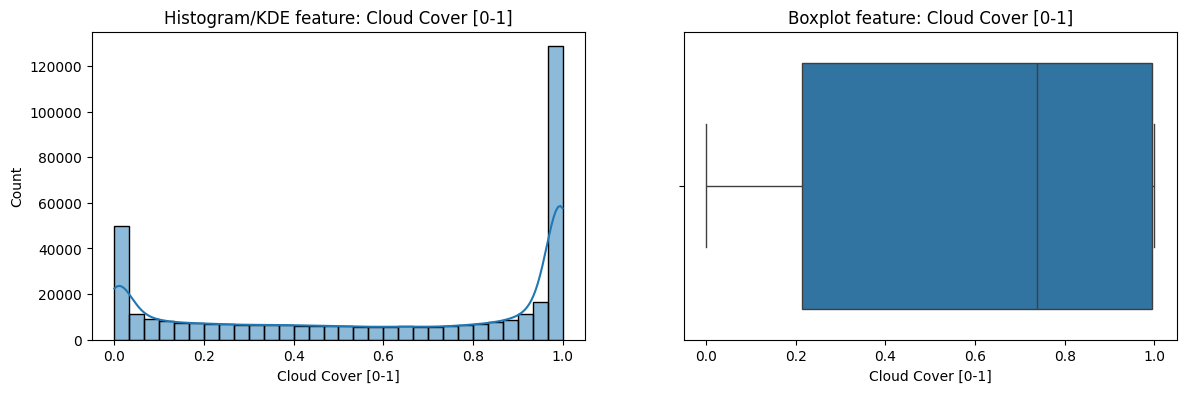

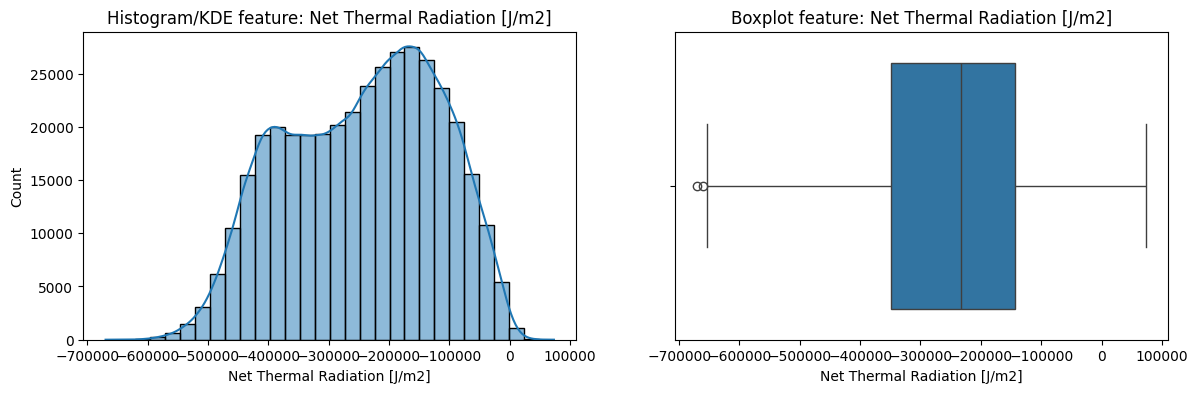

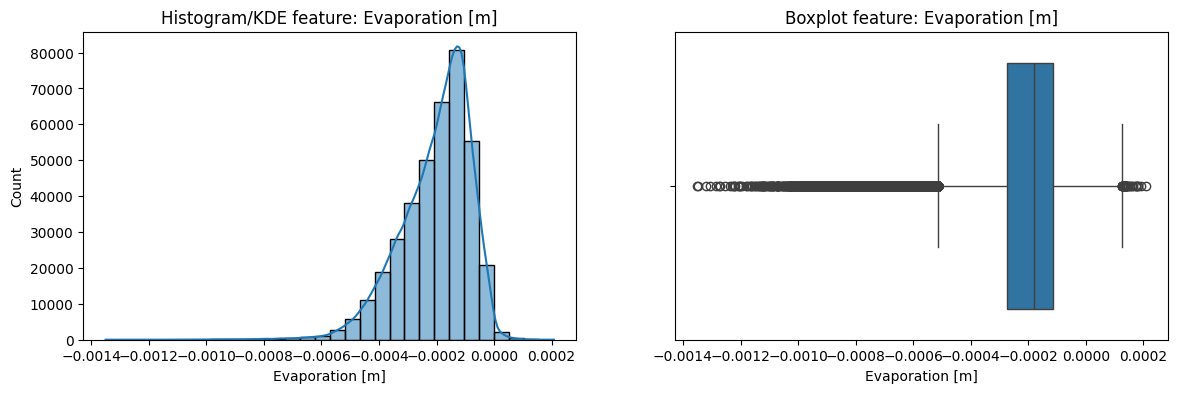

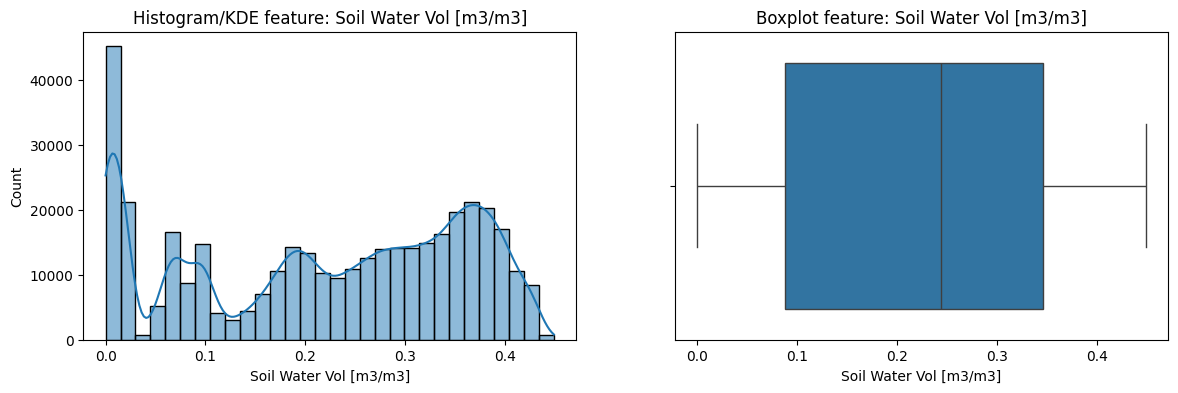

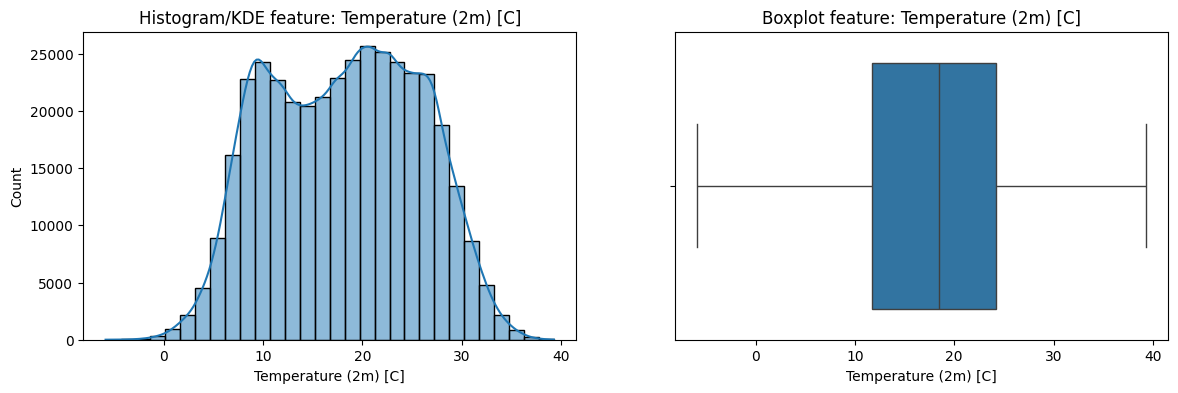

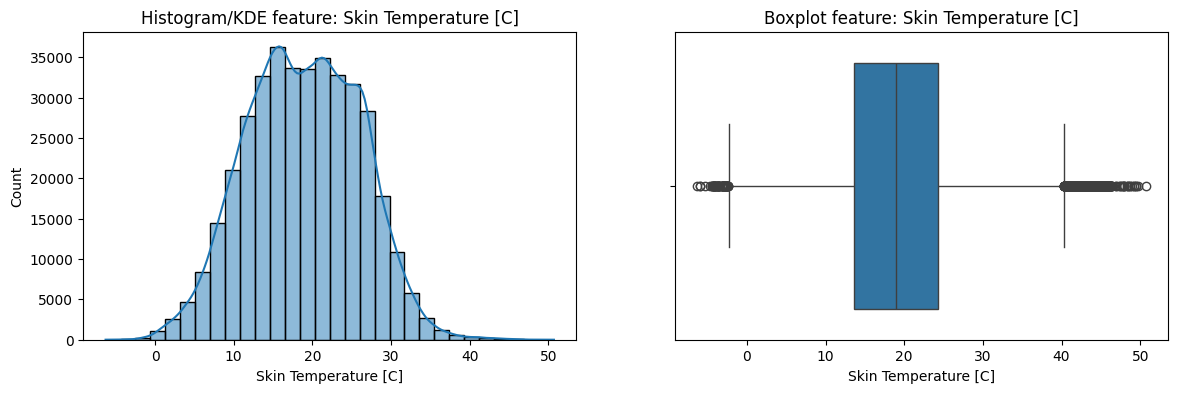

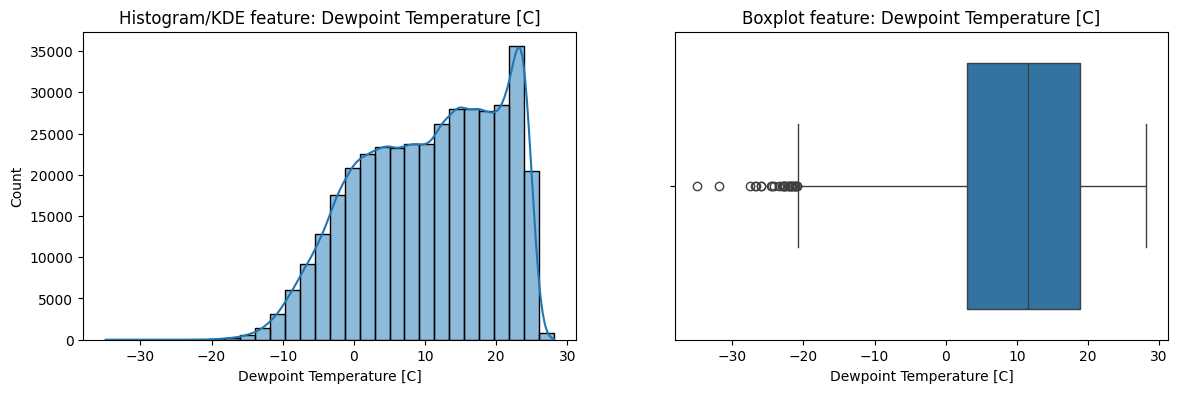

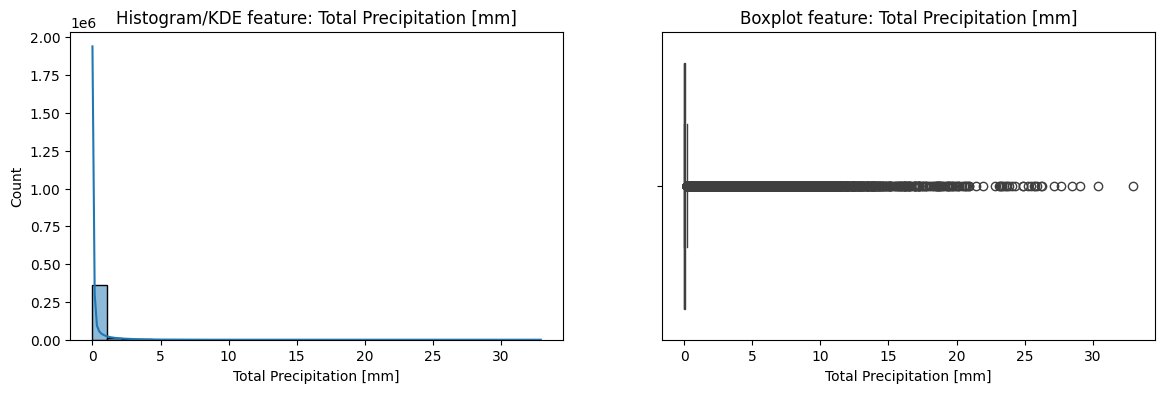

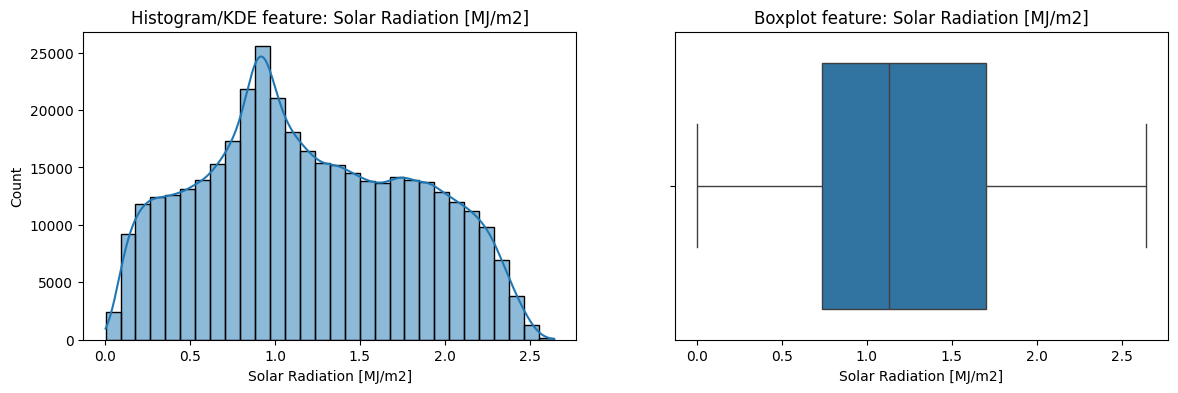

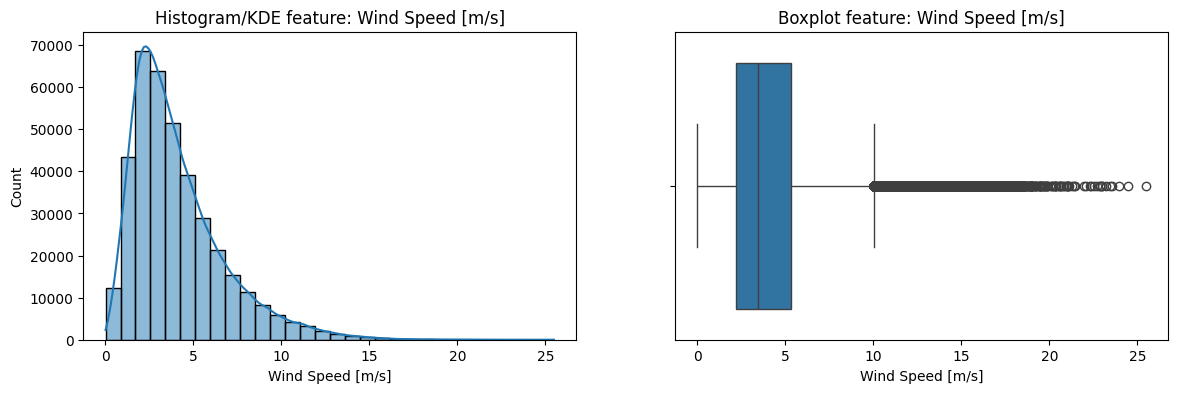

In [ ]:
for col in num_cols:
    fig, ax = plt.subplots(1,2, figsize=(14,4))
    sns.histplot(df_eda[col], kde=True, bins=30, ax=ax[0])
    ax[0].set_title(f"Histogram/KDE feature: {col}")
    sns.boxplot(x=df_eda[col], ax=ax[1])
    ax[1].set_title(f"Boxplot feature: {col}")
    plt.show()

1. **Temperature Features (`Temperature (2m)`, `Skin Temperature`)**
  - `Air Temperature (2m)` exhibit some kind of bimodal distribution at the peaks
  - `Skin Temperature` distribution reminds more of a normal than the one above.

    The `Skin Temperature` shows a wider range and higher maximum values reaching nearly 50 Celsius Degree compared to `Air tempreature`. This confirms the intense surface heating typical for urban areas.
2. **Wind Speed** - The Wind distribution is strongly **right-skewed** meaning that during modeling part we could do (log or Box-Cox transforamtions)
  - The majority of days in Tokyo experience calm to moderate winds around 1-5 m/s.

3. **Moisture & Precipitation (`Total Precipitation`, `Dewpoint`, `Soil Water`)**
  - `Total Precipitation` distribution is mostly `zero`, meaning most days are dry. The boxplot shows onlty outliers, representing heavy rainfall events.
  - `Dewpoint Temperature` strongly left-skewed distribution, dropping sharply after ~25 Celsius degree (because it is probably that this is a physical limit of moisture holding capacity in this climate)
  - `Soil Water Vol` multimodal distribution with a significant peak near 0, indicating periods of dry soil, most likely to paved urban surface.

4. **Clouds & Radiation (Cloud Cover, Solar Radiation, Net Thermal)**
  - `Cloud Cover` bimodal distrribution, days tend to be mostly clear (value ~0) or completly overcast (value ~1), with fewer partly cloudy dats in between.
  - `Solar Radiation` shows a wide not regular spread with peaked value near 1.
  - `Net thermal Radiation` only negative values, indicating that ground is losing heat to the atmosphere.

### **2.2) Features spread in time**

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383460 entries, 0 to 383459
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   latitude                      383460 non-null  float64       
 1   longitude                     383460 non-null  float64       
 2   Cloud Cover [0-1]             383460 non-null  float32       
 3   date                          383460 non-null  datetime64[ns]
 4   Net Thermal Radiation [J/m2]  383460 non-null  float32       
 5   Evaporation [m]               383460 non-null  float32       
 6   Soil Water Vol [m3/m3]        383460 non-null  float32       
 7   Temperature (2m) [C]          383460 non-null  float32       
 8   Skin Temperature [C]          383460 non-null  float32       
 9   Dewpoint Temperature [C]      383460 non-null  float32       
 10  Total Precipitation [mm]      383460 non-null  float32       
 11  Solar Radiati

In [ ]:
df_daily = df_eda.groupby('date').mean().reset_index()

In [ ]:
df_daily = df_daily.set_index('date')
df_daily.head()

,latitude,longitude,Cloud Cover [0-1],Net Thermal Radiation [J/m2],Evaporation [m],Soil Water Vol [m3/m3],Temperature (2m) [C],Skin Temperature [C],Dewpoint Temperature [C],Total Precipitation [mm],Solar Radiation [MJ/m2],Wind Speed [m/s]
date,,,,,,,,,,,,
1996-01-01,35.5,139.75,0.177273,-363550.21875,-0.000098,0.127337,8.781403,10.504827,-3.178133,0.000000,0.767071,5.130048
1996-01-02,35.5,139.75,0.401563,-385673.37500,-0.000139,0.122911,7.645741,10.416865,-1.660611,0.000136,0.991587,2.959705
1996-01-03,35.5,139.75,0.034445,-451746.71875,-0.000116,0.121034,12.075714,13.007156,3.955858,0.000654,1.043588,7.445736
1996-01-04,35.5,139.75,0.038525,-416198.53125,-0.000082,0.117934,6.729711,9.812659,-7.352058,0.000000,1.010867,3.417215
1996-01-05,35.5,139.75,0.392466,-433029.84375,-0.000087,0.114234,9.036037,11.475634,-1.825182,0.000000,1.041699,1.710084


#### Air temperature

Let's investigate how Air temperature changes in years.

In [ ]:
yearly_temp = df_daily['Temperature (2m) [C]'].resample('YE').mean()

In [ ]:
sns.set_style("whitegrid")

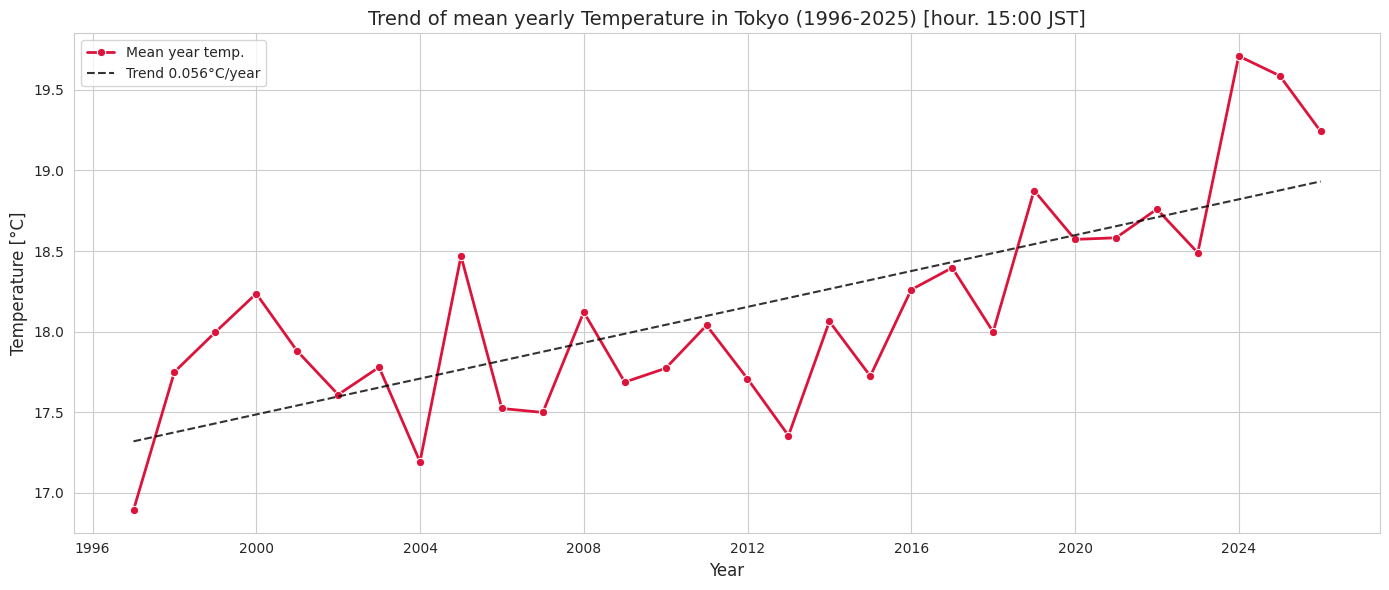

In [ ]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=yearly_temp, marker='o', color='crimson', label='Mean year temp.', linewidth=2)

x_num = np.arange(len(yearly_temp))
y_val = yearly_temp.values
slope, intercept = np.polyfit(x_num, y_val, 1)
trend_line = np.poly1d([slope, intercept])

plt.plot(yearly_temp.index, trend_line(x_num), "k--", label=f'Trend {slope:.3f}°C/year', alpha=0.8)

plt.title('Trend of mean yearly Temperature in Tokyo (1996-2025) [hour. 15:00 JST]', fontsize=14)
plt.ylabel('Temperature [°C]', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('temp_trend.png', dpi=300)
plt.show()

**Annual Trend Analysis**
- The annual mean temperature exhibits a clear incline trajectory. Linear regression analysis indicates a warming rate of approximately `+0.056°C per year` (as shown in the legend). The most recent years (2023-2024) appear to be among the warmest in the dataset, significantly exceeding the values from the beginning of the observation period.

In [ ]:
monthly_temp = df_daily['Temperature (2m) [C]'].resample('ME').mean()

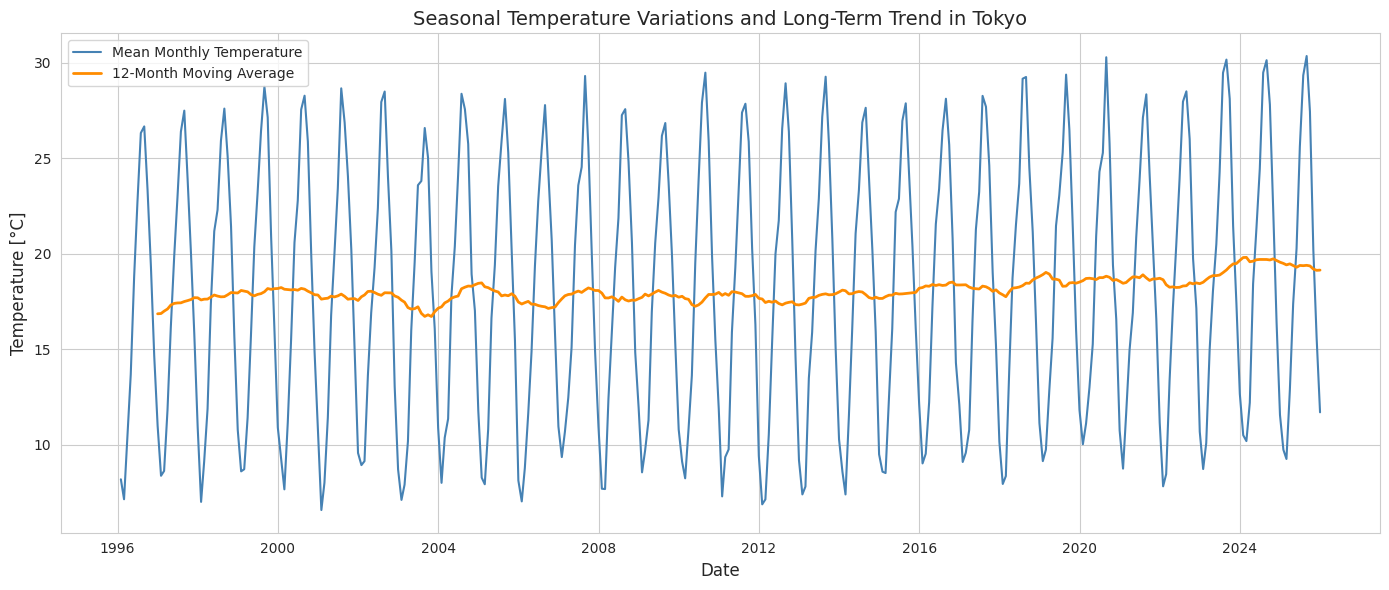

In [ ]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=monthly_temp, color='steelblue', label='Mean Monthly Temperature', linewidth=1.5)

rolling_mean = monthly_temp.rolling(window=12).mean()
plt.plot(rolling_mean.index, rolling_mean, color='darkorange', linewidth=2, label='12-Month Moving Average')

plt.title('Seasonal Temperature Variations and Long-Term Trend in Tokyo', fontsize=14)
plt.ylabel('Temperature [°C]', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

**Seasonal Decomposition**
- The monthly time series confirms the strong seasonality of the region. However, the magnitude of seasonal fluctuations tends to mask subtle long-term changes. By applying a `12-month rolling average`, we filtered out the seasonal noise to reveal climate signal.

Although the upward slope appears gradual relative to the seasonal spikes, it represents a substantial climatic shift. The baseline temperature has risen from approximately ~17°C in the 1996 to nearly ~20°C by 2025. This increase of ~3.0°C over a 30-year period is climatologically significant. It can be coused by urban "nature" itself and global warming.

Now we can move on from average values of temperature to the extreme ones. Let's calculate changes in Tropical Days.

In [ ]:
THRESHOLD_TEMP = 30.0

In [ ]:
hot_days_mask = df_daily['Temperature (2m) [C]'] > THRESHOLD_TEMP

In [ ]:
hot_days_count = hot_days_mask.resample('YE').sum()
hot_days_count

,Temperature (2m) [C]
date,
1996-12-31,2
1997-12-31,2
1998-12-31,3
1999-12-31,6
2000-12-31,2
2001-12-31,10
2002-12-31,13
2003-12-31,3
2004-12-31,13


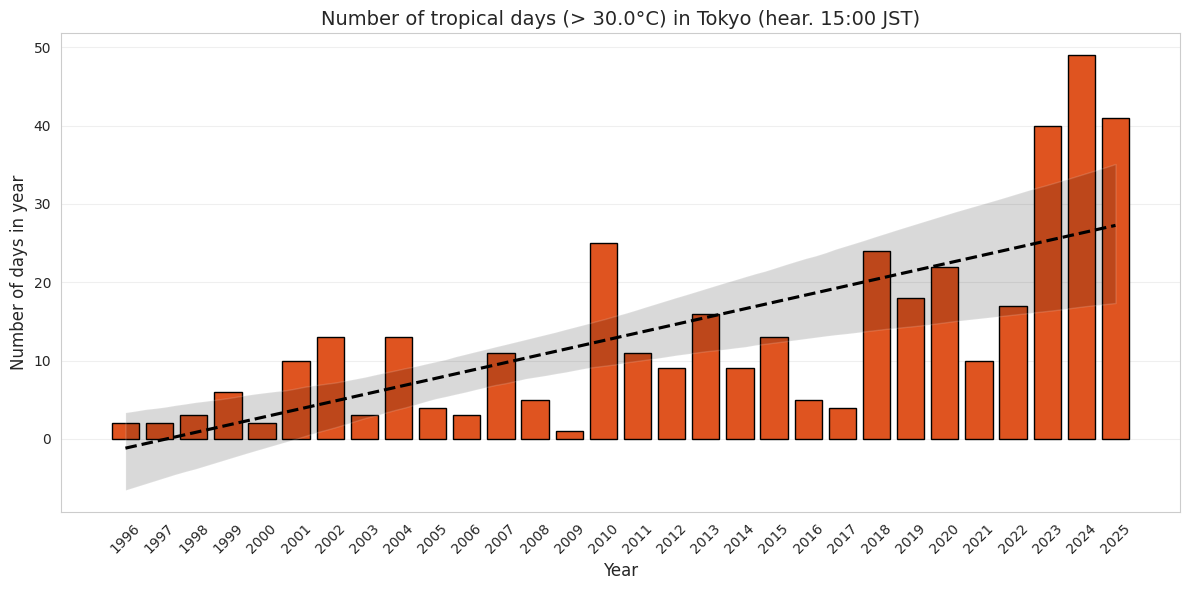

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(x=hot_days_count.index.year, y=hot_days_count.values, color='orangered', edgecolor='black')
sns.regplot(x=np.arange(len(hot_days_count)), y=hot_days_count.values, scatter=False, color='black', line_kws={'linestyle':'--'})

plt.title(f'Number of tropical days (> {THRESHOLD_TEMP}°C) in Tokyo (hear. 15:00 JST)', fontsize=14)
plt.ylabel('Number of days in year', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('tropical_days.png', dpi=300)
plt.show()

There is a clear evidence that number of tropical days drastically increased, especially over the last 3 years where there were over a 40 days when Air Temperature exceeded more than 30 degrees.

In [ ]:
pivot_temp = df_daily.pivot_table(
    values='Temperature (2m) [C]',
    index=df_daily.index.year,
    columns=df_daily.index.month,
    aggfunc='mean'
)

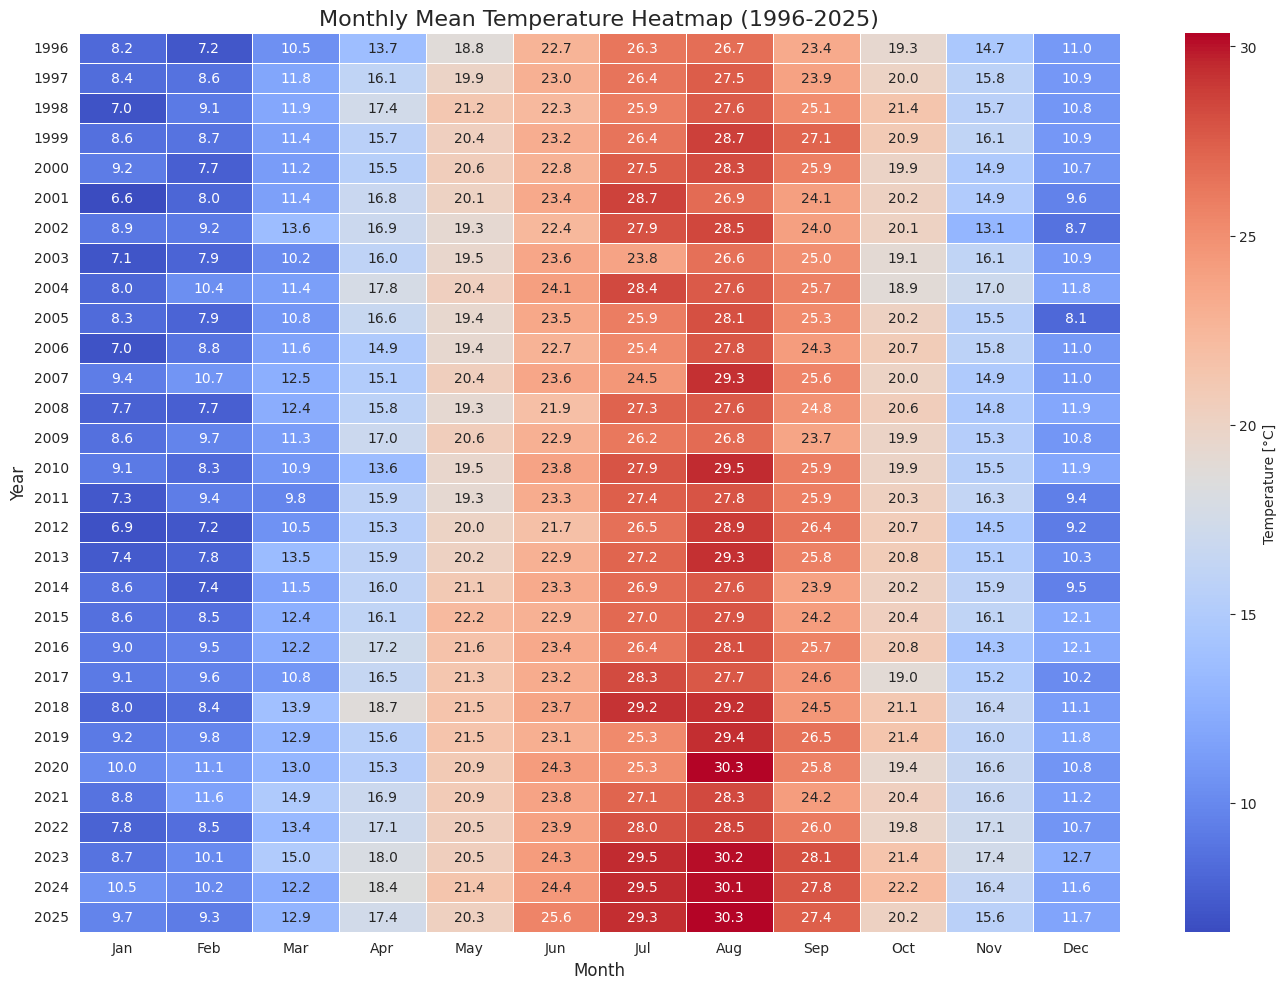

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    pivot_temp,
    cmap='coolwarm',
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cbar_kws={'label': 'Temperature [°C]'}
)

plt.title('Monthly Mean Temperature Heatmap (1996-2025)', fontsize=16)
plt.ylabel('Year', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.xticks(
    ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5],
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=0
)

plt.tight_layout()
plt.savefig('monthly_temp_heatmap.png', dpi=300)
plt.show()

**Summary of Seasonal Temperature Shifts**

The heatmap visualization (1996–2025) reveals a distinct transformation in Tokyo's thermal regime:

 - **Summer Intensification:** The peak summer months (July–August) show a clear trend towards extreme heat. August mean temperatures have shifted from ~26°C in the late 90s to consistently exceeding **30.0°C** in the 2020s, establishing a new baseline for summer intensity.

  - **Extension of the Summer Season:** The most critical finding is the warming of September. Historically a transition month (~23°C), it has recently recorded averages near **28°C** (e.g., 2023, 2024). This effectively extends the summer season well into autumn, delaying the seasonal cooling cycle.

**Temperature anomaly plot.**

In [ ]:
baseline_temp = yearly_temp.mean()

In [ ]:
anomalies = yearly_temp - baseline_temp

In [ ]:
colors = ['firebrick' if x > 0 else 'royalblue' for x in anomalies.values]

/tmp/ipython-input-3060723265.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


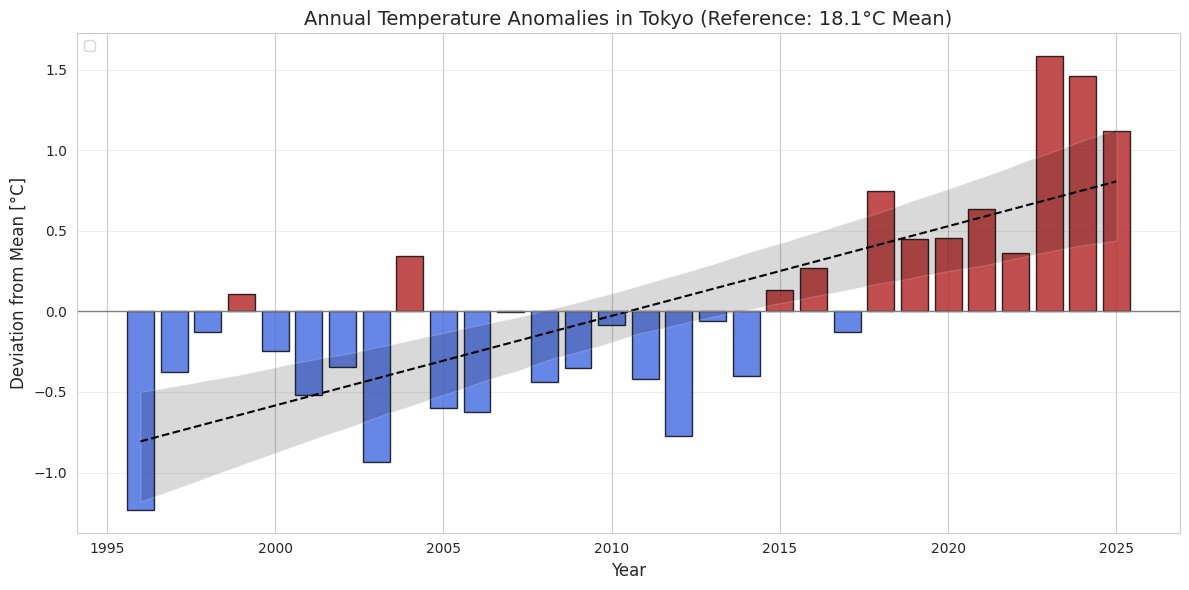

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(anomalies.index.year, anomalies.values, color=colors, edgecolor='black', alpha=0.8)
sns.regplot(
    x=yearly_temp.index.year,
    y=anomalies.values,
    scatter=False,
    color='black',
    line_kws={'linestyle':'--', 'linewidth': 1.5, 'label': 'Warming Trend'}
)


plt.axhline(0, color='gray', linewidth=1)

plt.title(f'Annual Temperature Anomalies in Tokyo (Reference: {baseline_temp:.1f}°C Mean)', fontsize=14)
plt.ylabel('Deviation from Mean [°C]', fontsize=12)
plt.xlabel('Year', fontsize=12)

plt.legend(loc='upper left')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('anomalies_temp.png', dpi=300)
plt.show()

A distinct climatic shift is observable around 2012. The period from 1996 to 2012 was characterized by negative anomalies (blue bars), indicating years generally cooler than the long-term average. In stark contrast, the period from 2013 onwards is dominated by positive anomalies (red bars).

This visualization confirms that the "average" climate of Tokyo has fundamentally changed. Temperatures that were considered normal in the late 1990s would now be statistically classified as anomalously cold events.

#### Total Precipitation

In [ ]:
yearly_rain_sum = df_daily['Total Precipitation [mm]'].resample('YE').sum()
yearly_rain_sum

,Total Precipitation [mm]
date,
1996-12-31,87.843620
1997-12-31,69.391975
1998-12-31,112.046783
1999-12-31,82.635559
2000-12-31,81.311256
2001-12-31,85.963188
2002-12-31,83.433434
2003-12-31,101.792702
2004-12-31,89.028687


In [ ]:
yearly_rain_max = df_daily['Total Precipitation [mm]'].resample('YE').max()
yearly_rain_max

,Total Precipitation [mm]
date,
1996-12-31,18.064091
1997-12-31,6.663173
1998-12-31,6.904548
1999-12-31,4.722840
2000-12-31,3.760134
2001-12-31,7.540676
2002-12-31,6.798907
2003-12-31,8.053521
2004-12-31,5.158098


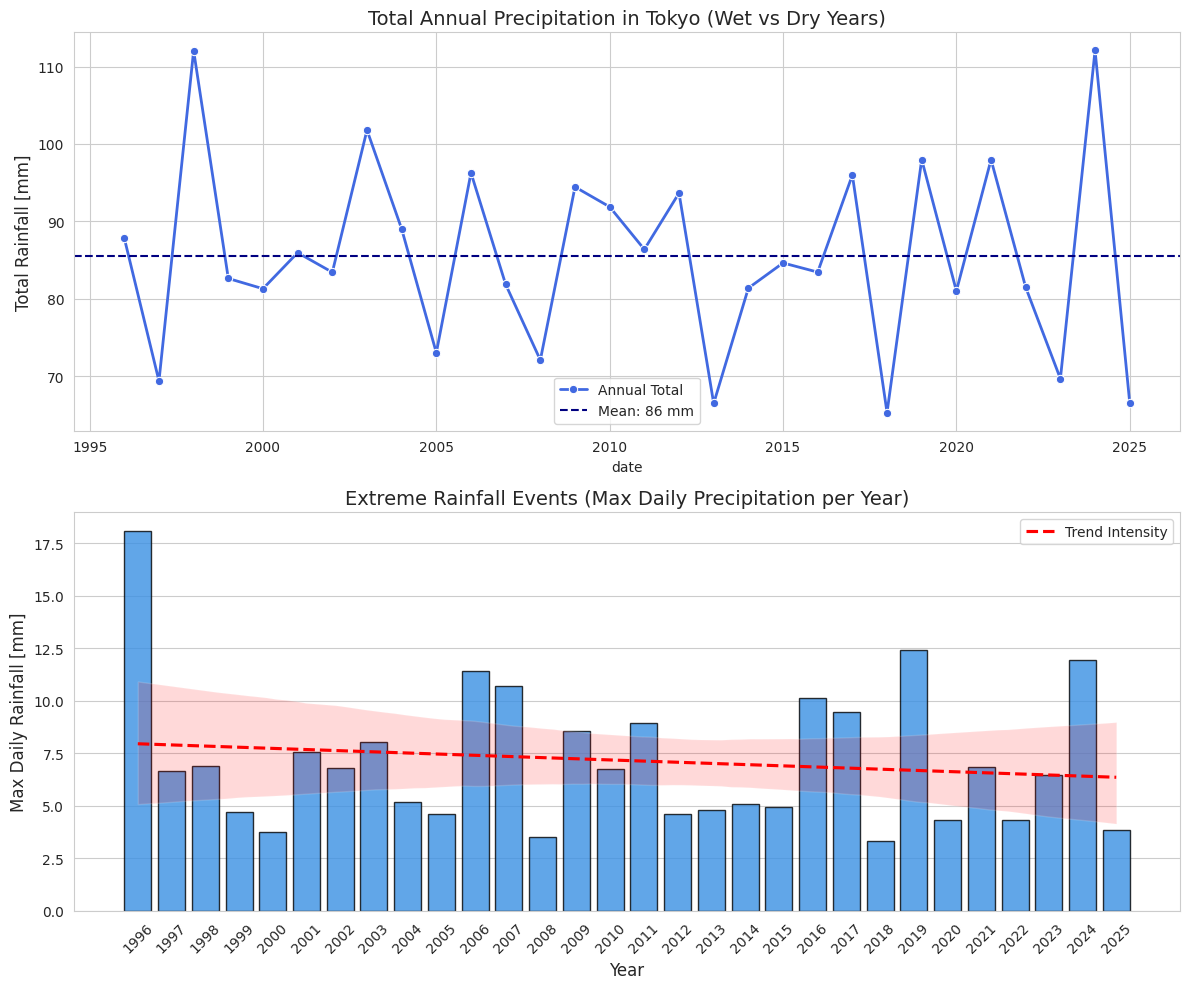

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# === PLOT 1: Total Annual Precipitation ===
sns.lineplot(
    x=yearly_rain_sum.index.year,
    y=yearly_rain_sum.values,
    ax=axes[0],
    marker='o',
    color='royalblue',
    linewidth=2,
    label='Annual Total'
)

mean_rain = yearly_rain_sum.mean()
axes[0].axhline(mean_rain, color='navy', linestyle='--', label=f'Mean: {mean_rain:.0f} mm')

axes[0].set_title('Total Annual Precipitation in Tokyo (Wet vs Dry Years)', fontsize=14)
axes[0].set_ylabel('Total Rainfall [mm]', fontsize=12)
axes[0].legend()

# === PLOT 2: Extreme Rainfall Events ===
sns.barplot(x=yearly_rain_max.index.year, y=yearly_rain_max.values, ax=axes[1], color='dodgerblue', edgecolor='black', alpha=0.8)

x_idx = np.arange(len(yearly_rain_max))
sns.regplot(
    x=x_idx,
    y=yearly_rain_max.values,
    ax=axes[1],
    scatter=False,
    color='red',
    line_kws={'linestyle':'--'},
    label='Trend Intensity'
)

axes[1].set_title('Extreme Rainfall Events (Max Daily Precipitation per Year)', fontsize=14)
axes[1].set_ylabel('Max Daily Rainfall [mm]', fontsize=12)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

- Total Annual Patterns (Top Chart): The variability remains the dominant feature. Despite global warming trends, the total annual precipitation recorded at 15:00 JST fluctuates around a stable mean of ~86 mm, showing no significant long-term increase or decrease in the local water budget.

- Extreme Events (Bottom Chart): The dataset reveals that recent extreme events (e.g., 2019, 2024) are not unprecedented. The year 1996 stands out as a historical maximum (~18 mm/day). Consequently, the linear trend over the last three decades appears slightly negative or stable, heavily influenced by this early outlier. This suggests that while thermal stress is increasing linearly, hydrological extremes in Tokyo follow a more complex, multi-decadal variability pattern rather than a simple upward linear trend.

In [ ]:
climate_pattern = df_daily.groupby(df_daily.index.month).mean()

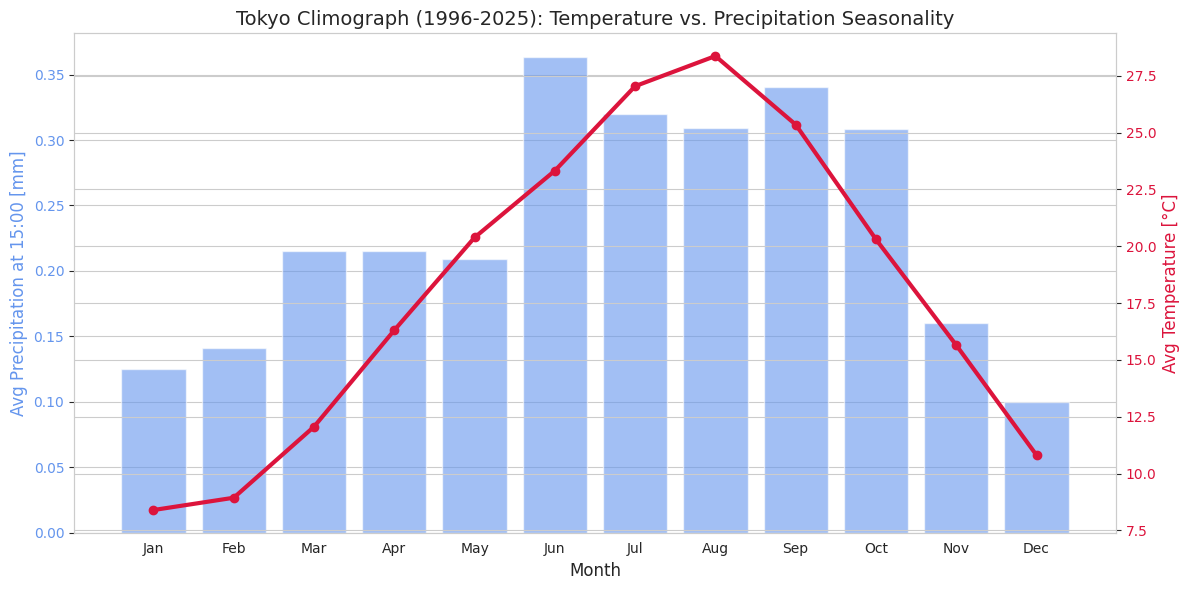

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Total precipitation
color_rain = 'cornflowerblue'
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Avg Precipitation at 15:00 [mm]', color=color_rain, fontsize=12)

bars = ax1.bar(climate_pattern.index, climate_pattern['Total Precipitation [mm]'], color=color_rain, alpha=0.6, label='Precipitation')
ax1.tick_params(axis='y', labelcolor=color_rain)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Temperature
ax2 = ax1.twinx()
color_temp = 'crimson'
ax2.set_ylabel('Avg Temperature [°C]', color=color_temp, fontsize=12)

line = ax2.plot(climate_pattern.index, climate_pattern['Temperature (2m) [C]'], color=color_temp, marker='o', linewidth=3, label='Temperature')
ax2.tick_params(axis='y', labelcolor=color_temp)

plt.title('Tokyo Climograph (1996-2025): Temperature vs. Precipitation Seasonality', fontsize=14)
ax1.grid(axis='x') #
plt.tight_layout()
plt.show()

In [ ]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring (Mar-May)'
    elif month in [6, 7, 8]:
        return 'Summer (Jun-Aug)'
    elif month in [9, 10, 11]:
        return 'Autumn (Sep-Nov)'
    else:
        return 'Winter (Dec-Feb)'

In [ ]:
df_daily['Season'] = df_daily.index.month.map(get_season)

/tmp/ipython-input-1980760612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Total Precipitation [mm]', data=df_daily, order=order, palette='Set2')


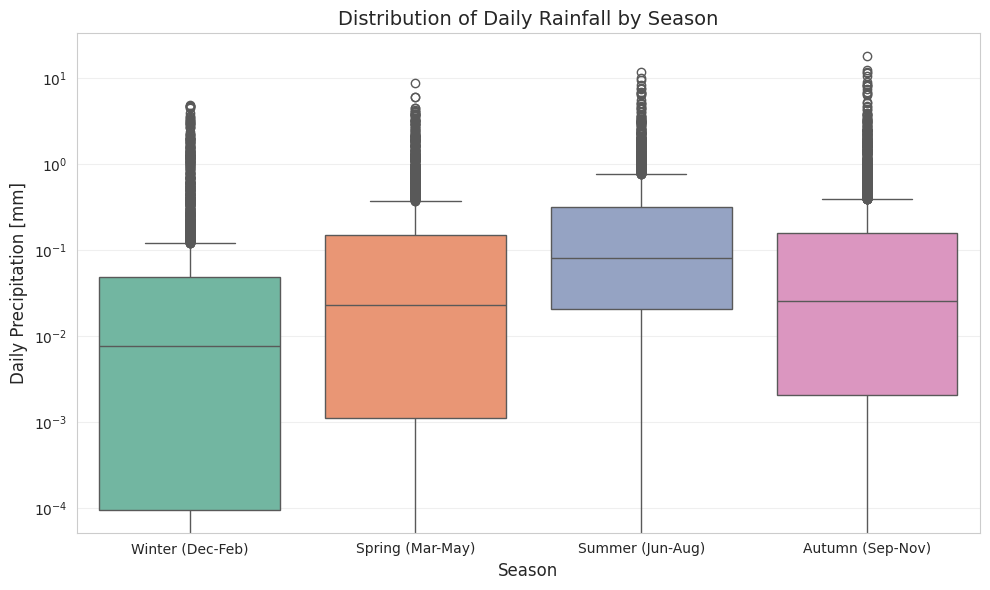

In [ ]:
plt.figure(figsize=(10, 6))
order = ['Winter (Dec-Feb)', 'Spring (Mar-May)', 'Summer (Jun-Aug)', 'Autumn (Sep-Nov)']

sns.boxplot(x='Season', y='Total Precipitation [mm]', data=df_daily, order=order, palette='Set2')

plt.title('Distribution of Daily Rainfall by Season', fontsize=14)
plt.ylabel('Daily Precipitation [mm]', fontsize=12)
plt.xlabel('Season', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

We can ask the question "Do warmer summers in Tokyo mean drought or, on the contrary, more rain?"

In [ ]:
yearly_stats = pd.DataFrame({
    'Temperature': df_daily['Temperature (2m) [C]'].resample('YE').mean(),
    'Precipitation': df_daily['Total Precipitation [mm]'].resample('YE').sum()
})

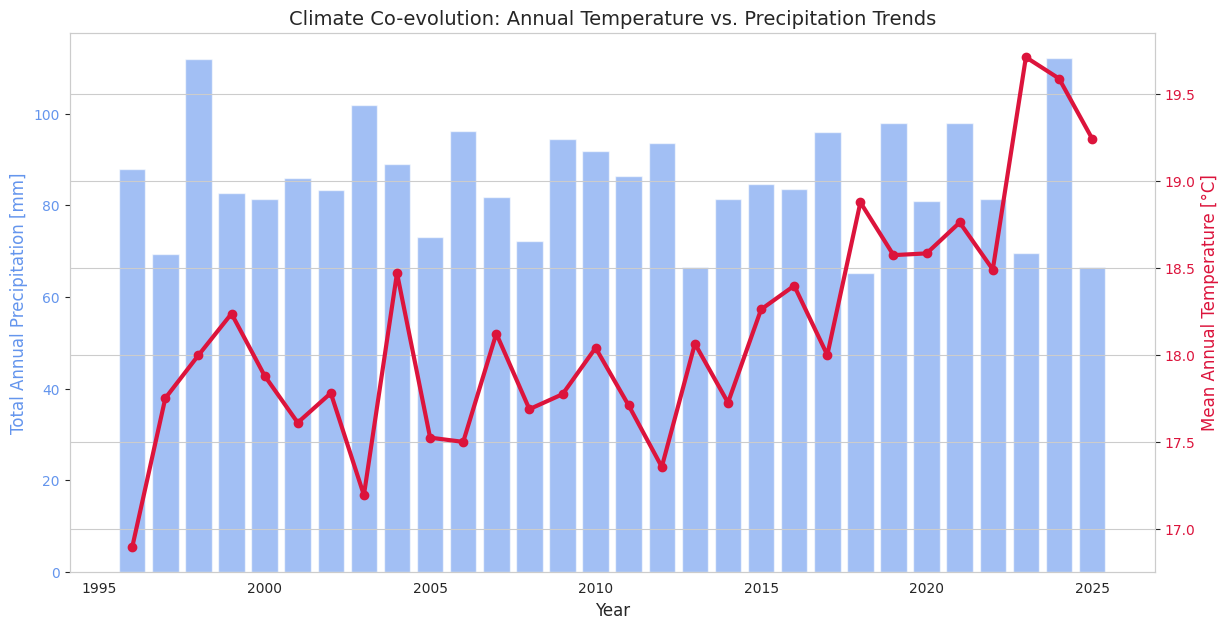

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left Axis: PRECIPITATION (Bars)
color_rain = 'cornflowerblue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Annual Precipitation [mm]', color=color_rain, fontsize=12)
ax1.bar(yearly_stats.index.year, yearly_stats['Precipitation'], color=color_rain, alpha=0.6, label='Total Precipitation')
ax1.tick_params(axis='y', labelcolor=color_rain)
ax1.grid(False) # Turn off grid for bars to keep it clean

# Right Axis: TEMPERATURE (Line)
ax2 = ax1.twinx()
color_temp = 'crimson'
ax2.set_ylabel('Mean Annual Temperature [°C]', color=color_temp, fontsize=12)
ax2.plot(yearly_stats.index.year, yearly_stats['Temperature'], color=color_temp, marker='o', linewidth=3, label='Mean Temperature')
ax2.tick_params(axis='y', labelcolor=color_temp)

plt.title('Climate Co-evolution: Annual Temperature vs. Precipitation Trends', fontsize=14)
plt.show()

The dual-axis chart examines the coupling between thermal and hydrological changes over the last three decades.

#### Wind Speed

We can investigate if wind speed will be decreasing because of increasing number of skyscrapers which infulence overall wind spread across the city.

In [ ]:
yearly_wind = df_daily['Wind Speed [m/s]'].resample('YE').mean()

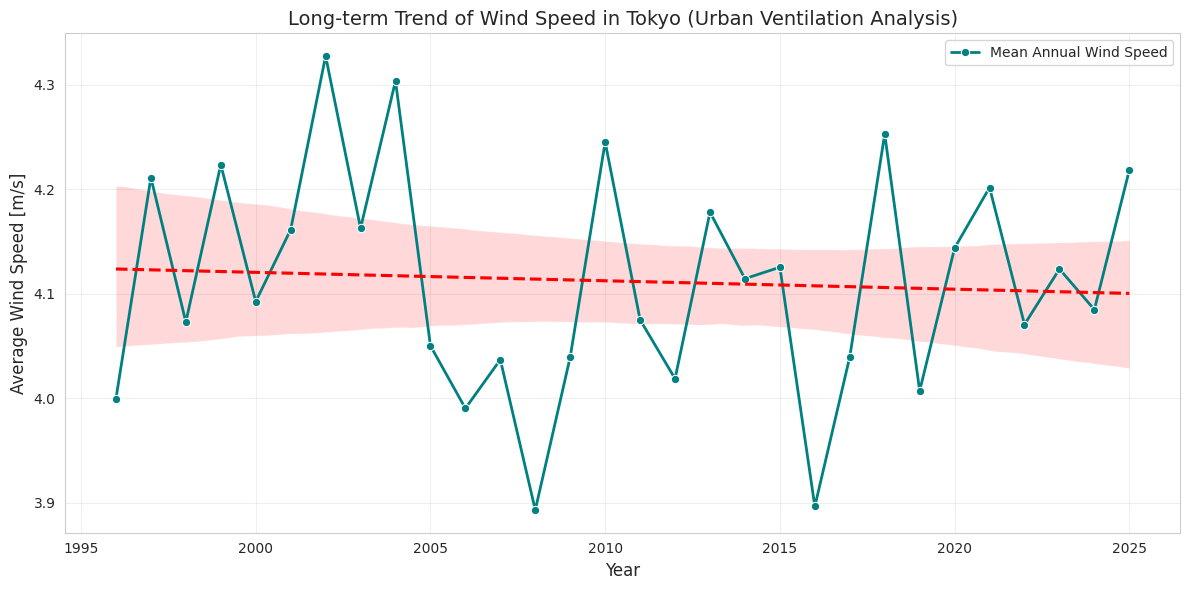

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_wind.index.year,
    y=yearly_wind.values,
    marker='o',
    color='teal',
    label='Mean Annual Wind Speed',
    linewidth=2
)

sns.regplot(
    x=yearly_wind.index.year,
    y=yearly_wind.values,
    scatter=False,
    color='red',
    line_kws={'linestyle':'--', 'label':'Linear Trend'}
)

plt.title('Long-term Trend of Wind Speed in Tokyo (Urban Ventilation Analysis)', fontsize=14)
plt.ylabel('Average Wind Speed [m/s]', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The lack of a sharp downward trend suggests that reduction in wind speed often seen in growing cities due to surface friction is not the primary driver of the observed warming in this specific dataset. The warming trend is likely driven more by thermal retention than by a loss of ventilation.

In [ ]:
df_daily['Month'] = df_daily.index.month

/tmp/ipython-input-1493358338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


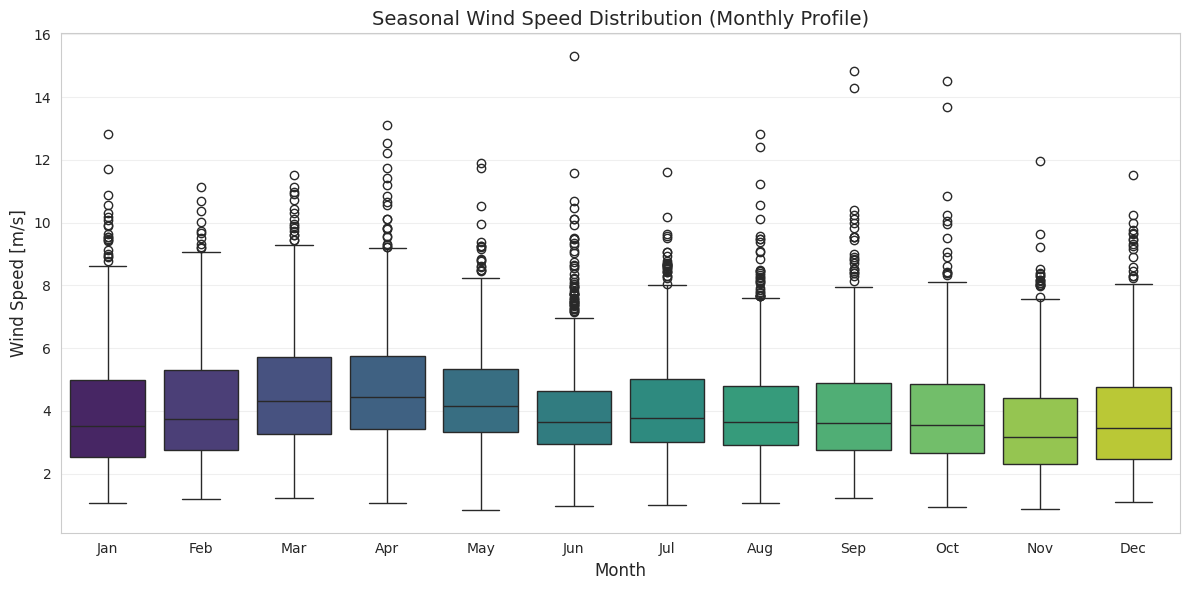

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_daily,
    x='Month',
    y='Wind Speed [m/s]',
    palette='viridis'
)

plt.title('Seasonal Wind Speed Distribution (Monthly Profile)', fontsize=14)
plt.ylabel('Wind Speed [m/s]', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.xticks(
    ticks=range(0, 12),
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The months of February through April exhibit the highest median wind speeds (indicated by the elevated position of the box plots), reflecting the seasonal transition and strong spring winds.

During the peak heat months (July–August), median wind speeds are relatively moderate. This suggests that during the hottest periods, the city does not consistently benefit from strong cooling winds, potentially exacerbating the heat stress.

#### Surface Net Solar Radiation

In [ ]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10956 entries, 1996-01-01 to 2025-12-29
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   latitude                      10956 non-null  float64
 1   longitude                     10956 non-null  float64
 2   Cloud Cover [0-1]             10956 non-null  float32
 3   Net Thermal Radiation [J/m2]  10956 non-null  float32
 4   Evaporation [m]               10956 non-null  float32
 5   Soil Water Vol [m3/m3]        10956 non-null  float32
 6   Temperature (2m) [C]          10956 non-null  float32
 7   Skin Temperature [C]          10956 non-null  float32
 8   Dewpoint Temperature [C]      10956 non-null  float32
 9   Total Precipitation [mm]      10956 non-null  float32
 10  Solar Radiation [MJ/m2]       10956 non-null  float32
 11  Wind Speed [m/s]              10956 non-null  float32
 12  Season                        10956 non-nul

In [ ]:
yearly_rad = df_daily['Solar Radiation [MJ/m2]'].resample('YE').mean()

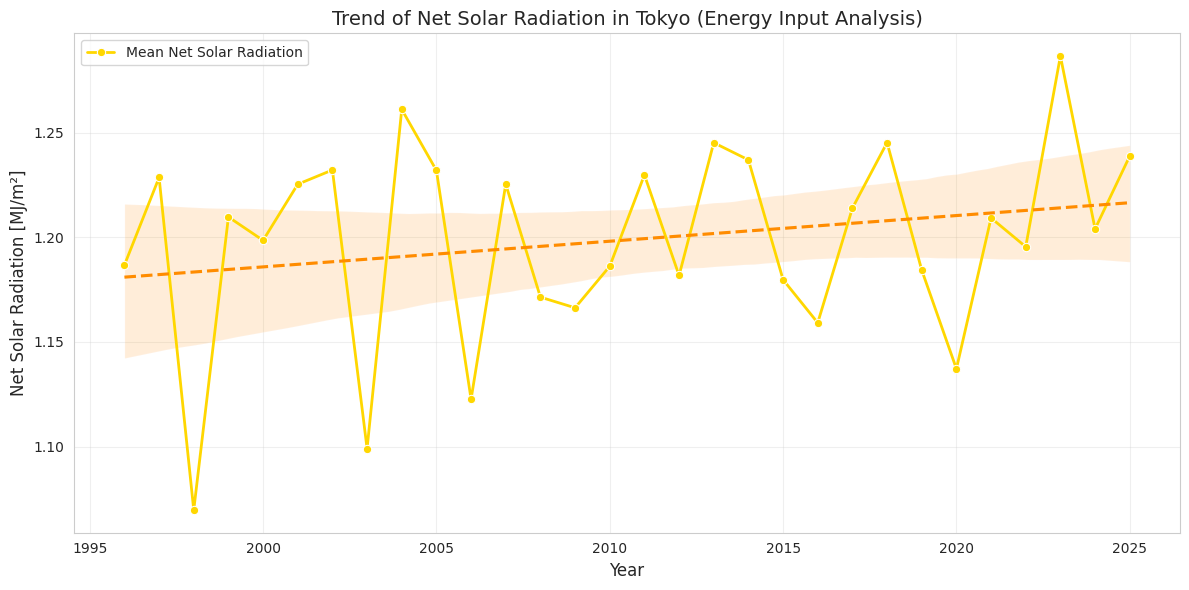

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_rad.index.year,
    y=yearly_rad.values,
    marker='o',
    color='gold',
    linewidth=2,
    label='Mean Net Solar Radiation'
)

sns.regplot(
    x=yearly_rad.index.year,
    y=yearly_rad.values,
    scatter=False,
    color='darkorange',
    line_kws={'linestyle':'--', 'label':'Trend'}
)

plt.title('Trend of Net Solar Radiation in Tokyo (Energy Input Analysis)', fontsize=14)
plt.ylabel('Net Solar Radiation [MJ/m²]', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

While increased solar input is a contributing factor, the slope of this trend is relatively gentle compared to the sharp rise in temperature anomalies. This reinforces the hypothesis that heat retention (via the Urban Heat Island effect and greenhouse gases) plays a more dominant role in Tokyo's warming than the direct increase in solar energy alone.

#### Soil Water Vol

In [ ]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10956 entries, 1996-01-01 to 2025-12-29
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   latitude                      10956 non-null  float64
 1   longitude                     10956 non-null  float64
 2   Cloud Cover [0-1]             10956 non-null  float32
 3   Net Thermal Radiation [J/m2]  10956 non-null  float32
 4   Evaporation [m]               10956 non-null  float32
 5   Soil Water Vol [m3/m3]        10956 non-null  float32
 6   Temperature (2m) [C]          10956 non-null  float32
 7   Skin Temperature [C]          10956 non-null  float32
 8   Dewpoint Temperature [C]      10956 non-null  float32
 9   Total Precipitation [mm]      10956 non-null  float32
 10  Solar Radiation [MJ/m2]       10956 non-null  float32
 11  Wind Speed [m/s]              10956 non-null  float32
 12  Season                        10956 non-nul

In [ ]:
yearly_rad = df_daily['Soil Water Vol [m3/m3]'].resample('YE').mean()

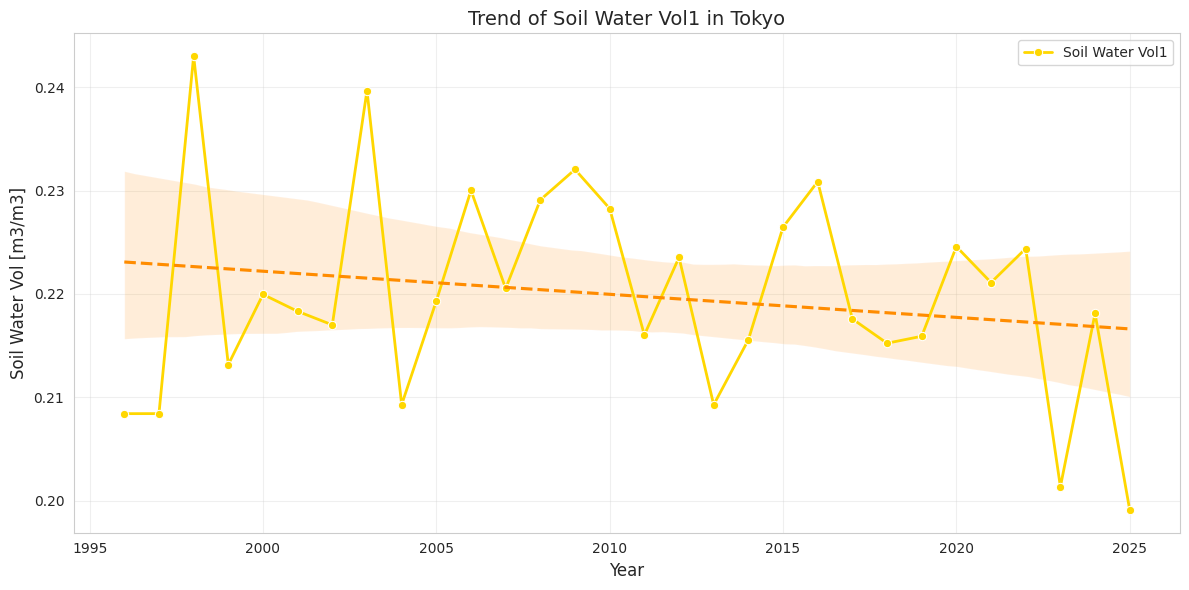

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_rad.index.year,
    y=yearly_rad.values,
    marker='o',
    color='gold',
    linewidth=2,
    label='Soil Water Vol1'
)

sns.regplot(
    x=yearly_rad.index.year,
    y=yearly_rad.values,
    scatter=False,
    color='darkorange',
    line_kws={'linestyle':'--', 'label':'Trend'}
)

plt.title('Trend of Soil Water Vol1 in Tokyo', fontsize=14)
plt.ylabel('Soil Water Vol [m3/m3]', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('soil_water_trend.png', dpi=300)
plt.show()

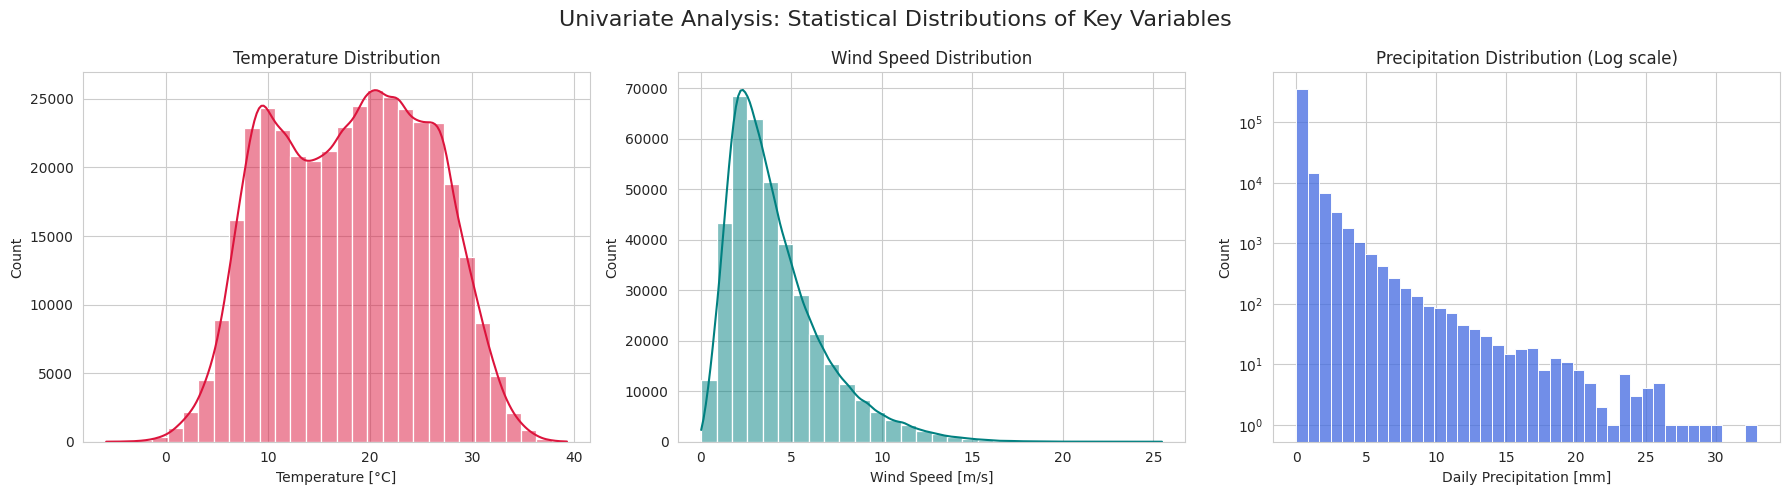

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Temperature distribution - biomodal - winter/summer
sns.histplot(df['Temperature (2m) [C]'], kde=True, color='crimson', bins=30, ax=axes[0])
axes[0].set_title('Temperature Distribution', fontsize=12)
axes[0].set_xlabel('Temperature [°C]')

# 2. Wind distribution
sns.histplot(df['Wind Speed [m/s]'], kde=True, color='teal', bins=30, ax=axes[1])
axes[1].set_title('Wind Speed Distribution', fontsize=12)
axes[1].set_xlabel('Wind Speed [m/s]')

# 3. Precipitation distribution
sns.histplot(df['Total Precipitation [mm]'], kde=False, color='royalblue', bins=40, ax=axes[2])
axes[2].set_yscale('log') # Logaritmic scale
axes[2].set_title('Precipitation Distribution (Log scale)', fontsize=12)
axes[2].set_xlabel('Daily Precipitation [mm]')

plt.suptitle('Univariate Analysis: Statistical Distributions of Key Variables', fontsize=16)
plt.tight_layout()

plt.savefig('distributions.png', dpi=300)
plt.show()

## **3) Multivariate**

#### Tokyo as a Urban Heat Island

Firstly, let's compare Skin Temperature and Temperature (2m) because our data has mostly concrete surface or water (Bay area). If surface temperature is higher than Air one, it means that city acts as a heat source.

In [ ]:
df_regional = df.groupby('date').mean()

In [ ]:
monthly_profile = df_regional.groupby(df_regional.index.month).mean()

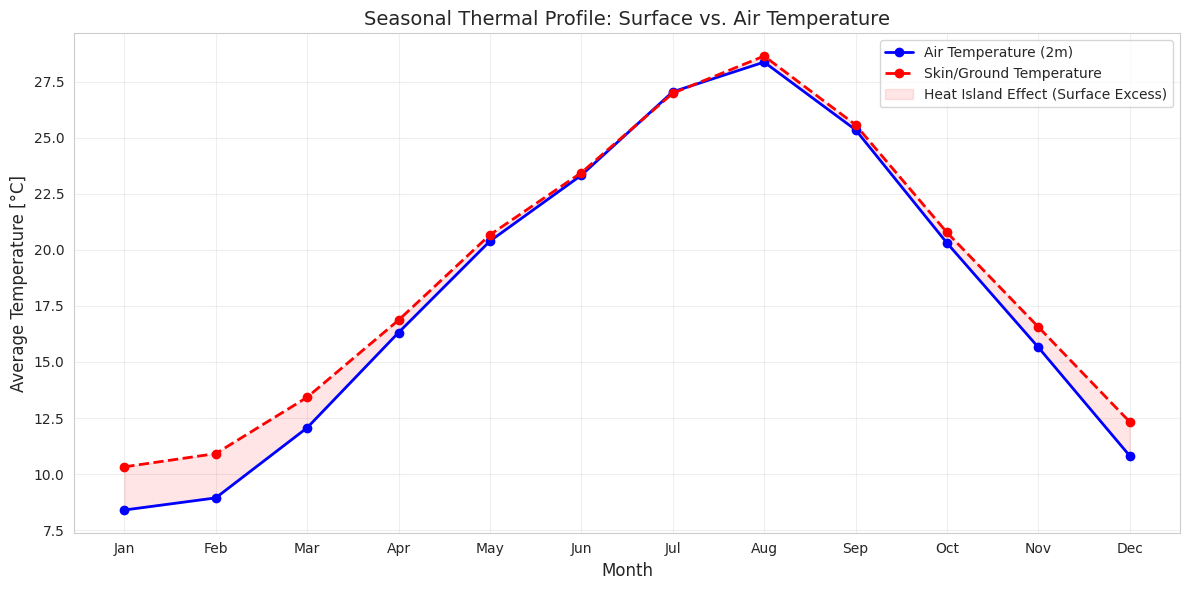

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_profile.index, monthly_profile['Temperature (2m) [C]'],
         label='Air Temperature (2m)', color='blue', marker='o', linewidth=2)

plt.plot(monthly_profile.index, monthly_profile['Skin Temperature [C]'],
         label='Skin/Ground Temperature', color='red', marker='o', linewidth=2, linestyle='--')

plt.fill_between(
    monthly_profile.index,
    monthly_profile['Temperature (2m) [C]'],
    monthly_profile['Skin Temperature [C]'],
    color='red', alpha=0.1, label='Heat Island Effect (Surface Excess)'
)

plt.title('Seasonal Thermal Profile: Surface vs. Air Temperature', fontsize=14)
plt.ylabel('Average Temperature [°C]', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('surface_air_temp.png', dpi=300)
plt.show()

In [ ]:
# Positive means = concrete heats air
df_regional['Thermal_Gap'] = df_regional['Skin Temperature [C]'] - df_regional['Temperature (2m) [C]']

In [ ]:
yearly_gap = df_regional['Thermal_Gap'].resample('YE').mean()

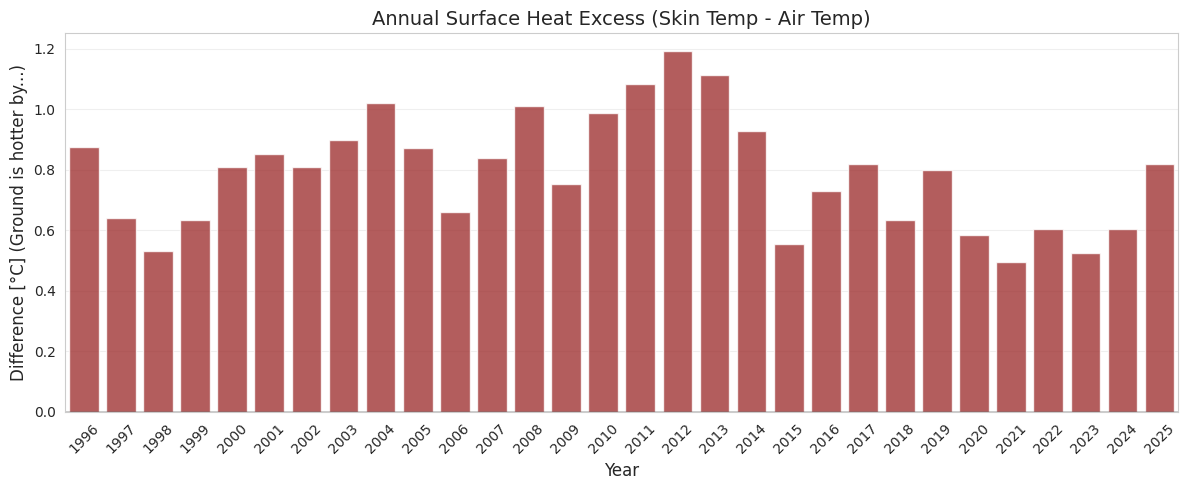

In [ ]:
plt.figure(figsize=(12, 5))

sns.barplot(x=yearly_gap.index.year, y=yearly_gap.values, color='firebrick', alpha=0.8)

plt.title('Annual Surface Heat Excess (Skin Temp - Air Temp)', fontsize=14)
plt.ylabel('Difference [°C] (Ground is hotter by...)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('bar_surface_air.png', dpi=300)
plt.show()

The comparative analysis of Skin Temperature (Surface) and Air Temperature (2m) provides direct evidence of the radiative forcing exerted by the urban landscape.

- The seasonal profile reveals that Skin Temperature consistently exceeds Air Temperature throughout the entire year. This confirms that the urban fabric (concrete, asphalt) and the adjacent water bodies (Tokyo Bay) possess higher thermal inertia than the atmosphere. Consequently, the surface acts as a persistent heat source, transferring energy to the lower atmosphere via sensible heat flux, thereby maintaining the Urban Heat Island (UHI) effect year-round.

- Notably, the thermal gap (indicated by the pink shaded area) is most pronounced in the winter months (November–February). This is likely driven by the Tokyo Bay effect, where the water body retains heat significantly longer than the cooling air, preventing surface temperatures from dropping as sharply as air temperatures.

Let's see how all the variables depend on each other.

In [ ]:
cols_to_analyze = [
    'Temperature (2m) [C]',
    'Skin Temperature [C]',
    'Dewpoint Temperature [C]',
    'Net Thermal Radiation [J/m2]',
    'Solar Radiation [MJ/m2]',
    'Cloud Cover [0-1]',
    'Total Precipitation [mm]',
    'Soil Water Vol [m3/m3]',
    'Evaporation [m]',
    'Wind Speed [m/s]'
]

In [ ]:
rename_map = {
    'Temperature (2m) [C]': 'Air Temp',
    'Skin Temperature [C]': 'Skin Temp',
    'Dewpoint Temperature [C]': 'Dewpoint',
    'Net Thermal Radiation [J/m2]': 'Therm Rad',
    'Solar Radiation [MJ/m2]': 'Solar Rad',
    'Cloud Cover [0-1]': 'Cloud',
    'Total Precipitation [mm]': 'Rain',
    'Soil Water Vol [m3/m3]': 'Soil Water',
    'Evaporation [m]': 'Evap',
    'Wind Speed [m/s]': 'Wind'
}

In [ ]:
df_corr = df_eda.groupby('date')[cols_to_analyze].mean().rename(columns=rename_map)

In [ ]:
corr_matrix = df_corr.corr()

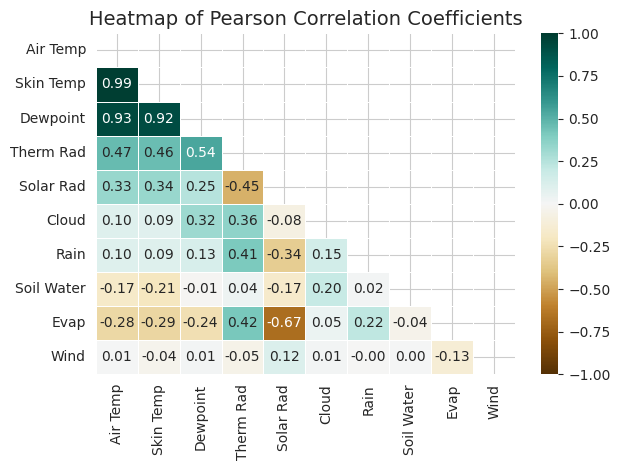

In [ ]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    mask=mask,
    cmap='BrBG',
    center=0,
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap of Pearson Correlation Coefficients", fontsize=14)
plt.tight_layout()
plt.show()

The Pearson correlation matrix reveals the fundamental physical couplings within the Tokyo climate system:

- The near-perfect correlation between Skin Temperature and Air Temperature confirms our earlier conclusions about the realationships between the surface thermodynamics (heating of the urban fabric and water) are the primary determinant of ambient air temperature.
- Very strong positive correlation with `Dewpoint Temperature` between other 2 confirms that heat events in Tokyo are intrinsically linked to high humidity.

#### Solar vs. Evaporation: Testing the energy source.

We will test if solar radiation indeed drives evaporation.

In [ ]:
from scipy import stats

In [ ]:
df_plot = df_eda.groupby('date').mean()

In [ ]:
r, p = stats.pearsonr(df_plot['Solar Radiation [MJ/m2]'], df_plot['Evaporation [m]'])
r, p

(np.float32(-0.6731481), np.float64(0.0))

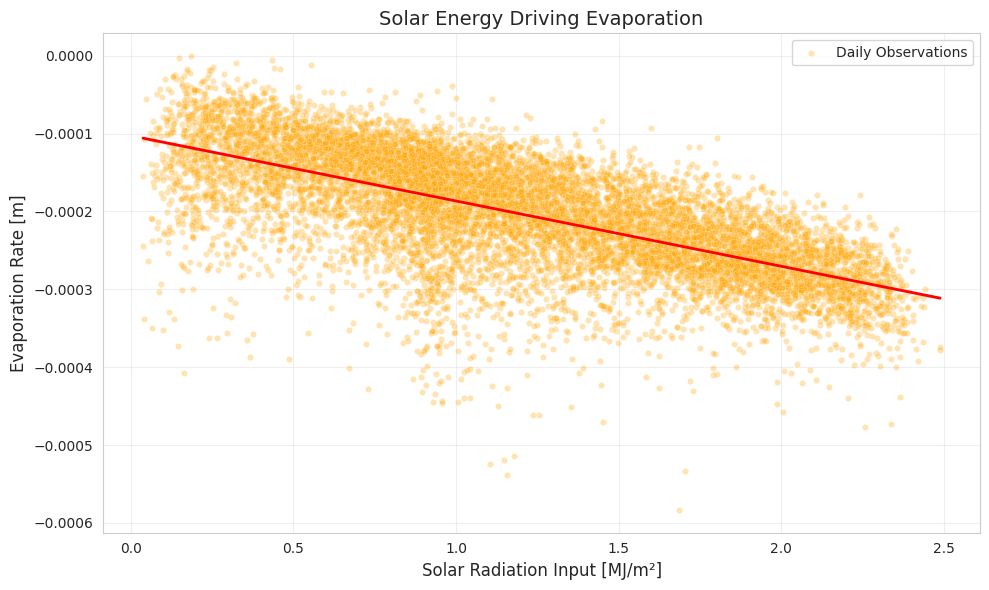

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='Solar Radiation [MJ/m2]',
    y='Evaporation [m]',
    color='orange',
    alpha=0.3,
    s=20,
    label='Daily Observations'
)

sns.regplot(
    data=df_plot,
    x='Solar Radiation [MJ/m2]',
    y='Evaporation [m]',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2, 'label': f'Linear Trend (r={r:.2f})'}
)

plt.title('Solar Energy Driving Evaporation', fontsize=14)
plt.xlabel('Solar Radiation Input [MJ/m²]', fontsize=12)
plt.ylabel('Evaporation Rate [m]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('solar_evaporation.png', dpi=300)
plt.show()

Evaporation is represented as a negative flux (water leaving the surface). Therefore, more negative values (moving downwards on the Y-axis) indicate higher evaporation rates.

This linear dependency proves that the "engine" for cooling is functional. If water is available, solar energy will effectively drive evaporation, converting sensible heat into latent heat and cooling the urban environment.

#### The "Sauna Effect" – Humidity and Thermal Radiation

The goal is to investigate the realtionship between atmospheric moisture content (represented by `Dewpoint Temperature`) and the region's energy budget (`Net thermal Radiation`). Wa want to determine whether high humidity levels contribute to heat retention in the Tokyo area.

We hypothesize a positive correaltion between Dewpoint Temperature and Net Thermal Radiation.

In [ ]:
r, p = stats.pearsonr(df_plot['Dewpoint Temperature [C]'], df_plot['Net Thermal Radiation [J/m2]'])
r, p

(np.float32(0.53952605), np.float64(0.0))

/tmp/ipython-input-175860197.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


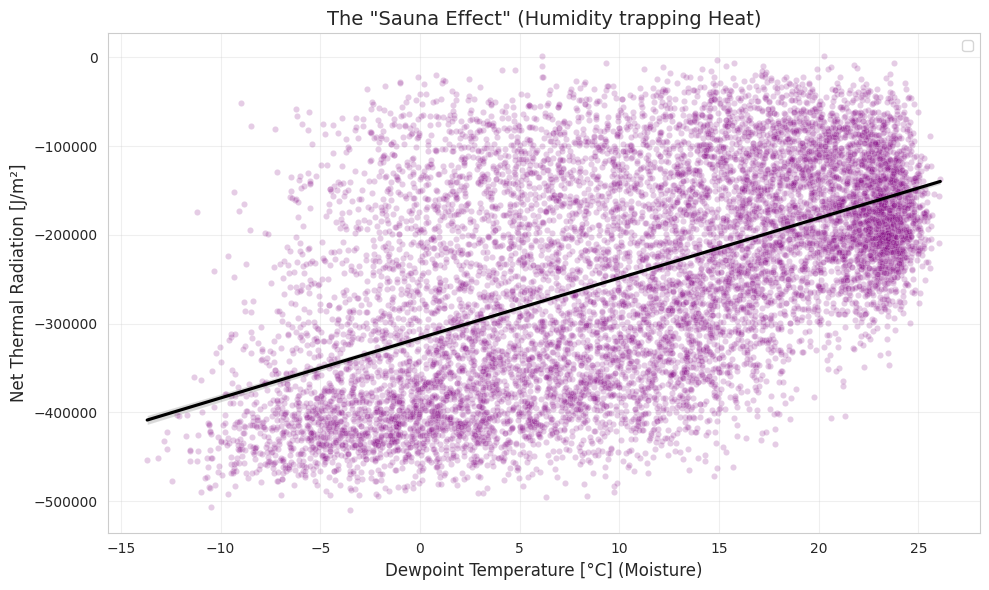

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='Dewpoint Temperature [C]',
    y='Net Thermal Radiation [J/m2]',
    color='purple',
    alpha=0.2,
    s=20
)

sns.regplot(
    data=df_plot,
    x='Dewpoint Temperature [C]',
    y='Net Thermal Radiation [J/m2]',
    scatter=False,
    color='black',
    line_kws={'label': f'Greenhouse Correlation (r={r:.2f})'}
)

plt.title('The "Sauna Effect" (Humidity trapping Heat)', fontsize=14)
plt.xlabel('Dewpoint Temperature [°C] (Moisture)', fontsize=12)
plt.ylabel('Net Thermal Radiation [J/m²]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('humidity radiation.png', dpi=300)
plt.show()

There is a distinct positive trend (indicated by the black regression line). As Dewpoint Temperature increases, the Net Thermal Radiation values increase significantly.

This confirms that high humidity blocks the release of longwave radiation from the surface. The moisture absorbs and re-radiates the heat back to the ground, preventing the city from cooling down, especially at night. This physical mechanism is the primary driver of "Tropical Nights" and extreme heat stress in Tokyo.


#### Does Evaporation Cool the Surface?

Having identified that solar radiation drives evaporation (Exp 1) and humidity traps heat (Exp 2), the final experiment investigates the direct impact of evaporation on surface temperature. We aim to quantify the cooling efficiency of the hydrological cycle in the urban context.

We hypothesize that higher evaporation rates act as a regulator for surface temperature.

In [ ]:
r, p = stats.pearsonr(df_plot['Evaporation [m]'], df_plot['Skin Temperature [C]'])
r, p

(np.float32(-0.29017353), np.float64(1.5826911443549357e-211))

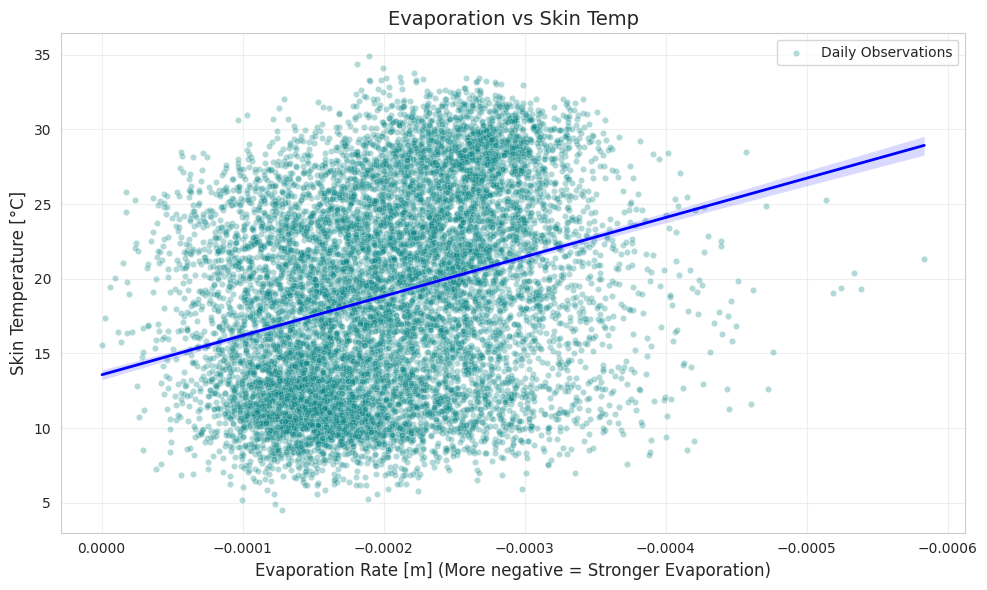

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='Evaporation [m]',
    y='Skin Temperature [C]',
    color='teal',
    alpha=0.3,
    s=20,
    label='Daily Observations'
)

sns.regplot(
    data=df_plot,
    x='Evaporation [m]',
    y='Skin Temperature [C]',
    scatter=False,
    color='blue',
    line_kws={'linewidth': 2, 'label': f'Cooling Interaction (r={r:.2f})'}
)

plt.title('Evaporation vs Skin Temp', fontsize=14)
plt.xlabel('Evaporation Rate [m] (More negative = Stronger Evaporation)', fontsize=12)
plt.ylabel('Skin Temperature [°C]', fontsize=12)

plt.gca().invert_xaxis()

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('evaporation_skin.png', dpi=300)
plt.show()

Although the initial hypothesis anticipated a negative correlation (cooling effect), the data reveals a positive correlation.

The positive slope indicates that high surface temperatures are the prerequisite for high evaporation rates. The sun heats the surface first, providing the energy required to turn water into vapor.

**Conclusion:** The experiment confirms that the urban surface actively responds to solar heating by evaporating moisture. This validates the "Sponge City" recommendation: providing more water availability will maximize this buffering capacity, preventing run-away heating effects during heatwaves.

Statistical tests on Target variable "Air Temperature"

In [ ]:
cols = [
    'Temperature (2m) [C]', 'Skin Temperature [C]', 'Dewpoint Temperature [C]',
    'Net Thermal Radiation [J/m2]', 'Solar Radiation [MJ/m2]',
    'Cloud Cover [0-1]', 'Total Precipitation [mm]',
    'Soil Water Vol [m3/m3]', 'Evaporation [m]', 'Wind Speed [m/s]'
]

rename_map = {
    'Temperature (2m) [C]': 'Air Temp',
    'Skin Temperature [C]': 'Skin Temp',
    'Dewpoint Temperature [C]': 'Dewpoint',
    'Net Thermal Radiation [J/m2]': 'Therm Rad',
    'Solar Radiation [MJ/m2]': 'Solar Rad',
    'Cloud Cover [0-1]': 'Cloud',
    'Total Precipitation [mm]': 'Rain',
    'Soil Water Vol [m3/m3]': 'Soil Water',
    'Evaporation [m]': 'Evap',
    'Wind Speed [m/s]': 'Wind'
}

df_stats = df_eda.groupby('date')[cols].mean().rename(columns=rename_map)


results = []
target = 'Air Temp'

for col in df_stats.columns:
    if col == target: continue


    clean_data = df_stats[[target, col]].dropna()


    r, p_value = stats.pearsonr(clean_data[target], clean_data[col])

    verdict = '✅ SIGNIFICANT' if p_value < 0.05 else '❌ NOT SIGNIFICANT'

    results.append({
        'Predictor': col,
        'Correlation (r)': r,
        'P-value': p_value,
        'Verdict': verdict
    })

stat_table = pd.DataFrame(results)
stat_table['Abs_Corr'] = stat_table['Correlation (r)'].abs()
stat_table = stat_table.sort_values(by='Abs_Corr', ascending=False).drop(columns=['Abs_Corr'])

print("--- STATISTICAL VERIFICATION OF HEATMAP (Target: Air Temp) ---")
print(stat_table.to_string(index=False, formatters={'Correlation (r)': '{:.3f}'.format, 'P-value': '{:.2e}'.format}))

--- STATISTICAL VERIFICATION OF HEATMAP (Target: Air Temp) ---
 Predictor Correlation (r)   P-value           Verdict
 Skin Temp           0.991  0.00e+00     ✅ SIGNIFICANT
  Dewpoint           0.932  0.00e+00     ✅ SIGNIFICANT
 Therm Rad           0.467  0.00e+00     ✅ SIGNIFICANT
 Solar Rad           0.330 8.69e-276     ✅ SIGNIFICANT
      Evap          -0.283 2.53e-200     ✅ SIGNIFICANT
Soil Water          -0.175  5.14e-76     ✅ SIGNIFICANT
     Cloud           0.096  1.22e-23     ✅ SIGNIFICANT
      Rain           0.095  1.56e-23     ✅ SIGNIFICANT
      Wind           0.006  5.27e-01 ❌ NOT SIGNIFICANT


## **4) Conclusion**
**1. Diagnostic Analysis: Urban Heat Island & Hydrological Stress**
The comprehensive descriptive and multivariate analysis of the ERA5 dataset has identified the primary physical drivers of local climate change in the Tokyo region:
- **Confirmation of the Urban Heat Island (UHI) Effect:** Comparative analysis revealed a persistent positive thermal gap between `Skin Temperature` and `Temperature (2m)`. The urban surface, characterized by high thermal inertia (concrete, asphalt), acts as a continuous heat source, radiatively heating the atmosphere from below.
- **Degradation of Water Resources:** Long-term trend analysis indicates a consistent decline in `Soil Water Volume`. This is a critical finding, as the correlation analysis established a statistically significant negative relationship ($r \approx -0.17$) between soil moisture and air temperature.

- **Disruption of the Cooling Cycle:** Physical experiments confirmed that while Evaporation in Tokyo is "energy-limited" (strongly driven by Solar Radiation), its cooling efficiency is increasingly constrained by water availability. The declining soil moisture limits the city's natural ability to cool via latent heat flux, causing a larger proportion of solar energy to be converted into sensible heat, thereby intensifying temperature extremes.

**2. Strategic Recommendation: The "Sponge City" Model**
To address the diagnosed drying trend and the intensification of the UHI effect, the implementation of the **"Sponge City"** strategy is recommended.Empirical evidence (specifically the correlation between Evaporation and Skin Temperature observed in Experiment 3) suggests that increasing water retention within the urban fabric is the most effective mechanism for moderating surface temperatures. Recommended actions include:
- **Infrastructure Adaptation:** Replacing impermeable surfaces with porous materials to reverse the declining trend of Soil Water Volume.
- **Blue-Green Infrastructure:** Developing retention parks and green roofs to maximize the conversion of available solar energy into evaporative cooling rather than surface heating.

**3. Machine Learning (ML) Strategy**
Addressing the feasibility of using ML techniques for future predictions: **Yes, the ERA5 dataset provides a robust foundation for developing predictive models.**
 - **A. Target Variable Definition:**
 The recommended target for the model is Temperature (2m) - This variable represents the direct metric for public health risks (heat stress), energy demand planning (air conditioning load), and social policy formulation.
 - **B. Feature Selection (Based on EDA):**
 Correlation analysis indicates that the following predictors are essential for a high-performance model:

    - Skin Temperature (Lagged Features): The strongest predictor ($r = 0.99$). The model should utilize surface temperatures from previous time steps ($t-1$, $t-2$) to predict future air temperature.
    - Solar Radiation: The primary energy input driving the system (positive correlation).
    - Soil Water Vol: A critical regulatory factor (negative correlation). Including this variable allows the model to learn that for the same solar input, drier soil results in higher air temperatures.
    - Dewpoint Temperature: Essential for modeling the "Greenhouse/Sauna Effect," where high humidity prevents nighttime radiative cooling.

**Conclusion:** An ML model trained on these physically validated features will enable not only accurate temperature forecasting but also the simulation of "what-if" scenarios (e.g., quantifying the temperature reduction resulting from a 10% increase in soil moisture).


